Replica de articulo https://www.quantconnect.com/research/18987/portfolio-construction-using-topological-data-analysis/p1 

# Librerías

In [35]:
import pandas as pd
import numpy as np
import random

import plotly
import requests
from bs4 import BeautifulSoup
import ruptures as rpt
import yfinance as yf

import plotly.graph_objects as go
import matplotlib.pyplot as plt

import kmapper as km
import subprocess
import sys
import networkx as nx
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "nbformat>=4.2.0"])
import sklearn.cluster

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import DBSCAN, KMeans
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots


# Datos

## Sacar tickers

In [36]:

# URL de la lista del S&P 500
url = "https://www.slickcharts.com/sp500"


# Hacer la petición con headers para evitar bloqueos
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}
response = requests.get(url, headers=headers)
response.raise_for_status()  # Raise exception for bad status codes

# Parsear el HTML
soup = BeautifulSoup(response.text, 'html.parser')

# Encontrar la tabla
table = soup.find('table')

if table:
    # Leer la tabla con pandas
    df = pd.read_html(str(table))[0]
    
    # Extraer los tickers
    if 'Symbol' in df.columns:
        tickers = df['Symbol'].tolist()
        print(f"Found {len(tickers)} tickers")
        print("First 10 tickers:", tickers[:10])
    else:
        print("Available columns:", df.columns.tolist())

    # Extraer los pesos
    if 'Weight' in df.columns:
        weights = df['Weight'].tolist()
        print(f"Found {len(weights)} weights")
        print("First 10 weights:", weights[:10])
    else:
        print("Available columns:", df.columns.tolist())
else:
    print("No table found on the page")

# En la lista de ticker, reemplazar los "." por "-"
tickers = [ticker.replace('.', '-') for ticker in tickers]
print("Tickers after replacement:", tickers[:10])

Found 503 tickers
First 10 tickers: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'BRK.B']
Found 503 weights
First 10 weights: ['7.13%', '6.67%', '5.88%', '3.99%', '3.24%', '3.07%', '3.02%', '2.60%', '2.30%', '1.79%']
Tickers after replacement: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'BRK-B']


## Historicos

In [37]:
#START_DATE='2015-01-01'
START_DATE='2022-01-01'
END_DATE='2025-11-01'
AN_DATE='2024-01-01'

In [38]:
# -----------------------------
# -----------------------------
# Descargar precios históricos
# -----------------------------
print(f"🔍 Descargando datos para {len(tickers)} tickers del S&P 500...")
all_tickers_data_raw = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']

# Identificar tickers con datos faltantes ANTES de eliminarlos
tickers_antes = set(all_tickers_data_raw.columns) if hasattr(all_tickers_data_raw, 'columns') else set()
all_tickers_data = all_tickers_data_raw.dropna(axis=1)  # eliminar columnas con datos faltantes
tickers_despues = set(all_tickers_data.columns)

# Tickers eliminados por datos incompletos
tickers_eliminados = tickers_antes - tickers_despues
tickers_solicitados_set = set(tickers)
tickers_no_descargados = tickers_solicitados_set - tickers_antes

# DIVIDIR EN DOS PERIODOS
# Período de análisis: desde START_DATE hasta AN_DATE
analysis_data = all_tickers_data.loc[START_DATE:AN_DATE]
tickers_data = analysis_data  # Datos para entrenamiento/análisis

# Período de validación: desde AN_DATE hasta END_DATE
validation_data = all_tickers_data.loc[AN_DATE:END_DATE]  # Datos para validación

print(f"\n✅ Datos descargados:")
print(f"   📊 Total: {all_tickers_data.shape} (desde {START_DATE} hasta {END_DATE})")
print(f"   📊 Período de análisis: {tickers_data.shape} (desde {START_DATE} hasta {AN_DATE})")
print(f"   📊 Período de validación: {validation_data.shape} (desde {AN_DATE} hasta {END_DATE})")

print(f"\n⚠️  DIAGNÓSTICO DE TICKERS:")
print(f"   📋 Tickers solicitados: {len(tickers)}")
print(f"   ✅ Tickers con datos completos: {len(tickers_despues)}")
print(f"   ❌ Tickers eliminados (datos incompletos): {len(tickers_eliminados)}")
if len(tickers_no_descargados) > 0:
    print(f"   🚫 Tickers no encontrados en yfinance: {len(tickers_no_descargados)}")

if len(tickers_eliminados) > 0:
    print(f"\n   Tickers eliminados por datos faltantes (primeros 20):")
    print(f"   {', '.join(sorted(list(tickers_eliminados)))}")

if len(tickers_no_descargados) > 0:
    print(f"\n   Tickers no encontrados (primeros 10):")
    print(f"   {', '.join(sorted(list(tickers_no_descargados)))}")

🔍 Descargando datos para 503 tickers del S&P 500...


[*********************100%***********************]  503 of 503 completed


✅ Datos descargados:
   📊 Total: (962, 495) (desde 2022-01-01 hasta 2025-11-01)
   📊 Período de análisis: (501, 495) (desde 2022-01-01 hasta 2024-01-01)
   📊 Período de validación: (461, 495) (desde 2024-01-01 hasta 2025-11-01)

⚠️  DIAGNÓSTICO DE TICKERS:
   📋 Tickers solicitados: 503
   ✅ Tickers con datos completos: 495
   ❌ Tickers eliminados (datos incompletos): 8

   Tickers eliminados por datos faltantes (primeros 20):
   CEG, GEHC, GEV, KVUE, Q, SOLS, SOLV, VLTO


In [39]:
## Datos S&P500
# Descargar SPY para benchmark
SPY_data = yf.download('SPY', start=START_DATE, end=END_DATE, auto_adjust=True)['Close']

# Verificar si es Serie o DataFrame y convertir apropiadamente
if isinstance(SPY_data, pd.Series):
    SPY = SPY_data.to_frame(name='SPY')
else:
    # Si ya es DataFrame, asegurarse que la columna se llame 'SPY'
    SPY = SPY_data.to_frame() if len(SPY_data.shape) == 1 else SPY_data
    if 'SPY' not in SPY.columns:
        SPY.columns = ['SPY']

# Dividir en períodos
SPY_analysis = SPY.loc[START_DATE:AN_DATE]
SPY_validation = SPY.loc[AN_DATE:END_DATE]

print(f"✅ SPY descargado:")
print(f"   📊 SPY_analysis: {SPY_analysis.shape}")
print(f"   📊 SPY_validation: {SPY_validation.shape}")
print(f"   📋 Columnas: {SPY_analysis.columns.tolist()}")

[*********************100%***********************]  1 of 1 completed

✅ SPY descargado:
   📊 SPY_analysis: (501, 1)
   📊 SPY_validation: (461, 1)
   📋 Columnas: ['SPY']


## Info financiera

In [40]:
from datetime import timedelta
import pandas as pd

def marketcap_en_fecha(ticker, fecha):
    # Convert string to datetime if needed
    if isinstance(fecha, str):
        fecha = pd.to_datetime(fecha)
    
    t = yf.Ticker(ticker)
    
    # Use a wider date range to ensure data availability
    fecha_inicio = fecha - timedelta(days=7)  # Look back 7 days
    
    # Get historical data
    history = t.history(start=fecha_inicio, end=fecha)
    shares = t.get_shares_full(start=fecha_inicio, end=fecha)
    
    # Validate data exists
    if history.empty or 'Close' not in history.columns:
        raise ValueError(f"No price data for {ticker} around {fecha}")
    if shares.empty:
        raise ValueError(f"No shares data for {ticker} around {fecha}")
    
    # Get the closest available data to the target date
    price = history["Close"].iloc[-1]  # Most recent price
    shares_count = shares.iloc[-1]     # Most recent share count
    
    return price * shares_count

# Example usage
marketcap_en_fecha("AVGO", AN_DATE)

51197756419.65918

In [41]:
# =======================================================
# 📊 RECOPILACIÓN DE INFORMACIÓN FUNDAMENTAL DE TICKERS
# =======================================================

import os

# Verificar si el archivo ya existe
csv_filename = 'sp500_ticker_info_database.csv'

if os.path.exists(csv_filename):
    # ✅ ARCHIVO EXISTE - Cargar datos existentes
    print("✅ Archivo 'sp500_ticker_info_database.csv' encontrado")
    print("📂 Cargando información desde archivo guardado...")
    print("=" * 80)
    
    try:
        ticker_info_df = pd.read_csv(csv_filename, index_col=0)
        
        # Convertir DataFrame a diccionario para ticker_info_db
        ticker_info_db = ticker_info_df.to_dict('index')
        
        print(f"✅ Datos cargados exitosamente")
        print(f"   📊 Total de tickers: {len(ticker_info_df)}")
        print(f"   📋 Columnas: {len(ticker_info_df.columns)}")
        print(f"\n💡 Para actualizar los datos, elimina el archivo '{csv_filename}' y vuelve a ejecutar esta celda")
        
    except Exception as e:
        print(f"❌ Error al cargar el archivo: {e}")
        print(f"⚠️  Se procederá a descargar los datos nuevamente...")
        # Si hay error, forzar descarga
        os.remove(csv_filename) if os.path.exists(csv_filename) else None
        ticker_info_df = None

else:
    # ❌ ARCHIVO NO EXISTE - Descargar información
    print("⚠️  Archivo 'sp500_ticker_info_database.csv' no encontrado")
    print("🔍 Descargando información detallada de todos los tickers del S&P 500...")
    print("⏱️  Esto puede tardar varios minutos...")
    print("=" * 80)
    
    ticker_info_db = {}
    failed_tickers = []
    error_details = {}  # Guardar detalles de errores
    
    for idx, ticker in enumerate(tickers, 1):
        try:
            # Mostrar progreso cada 50 tickers
            if idx % 50 == 0 or idx == 1:
                print(f"   Procesando ticker {idx}/{len(tickers)}: {ticker}")
            
            # Paso 1: Obtener info básica
            stock = yf.Ticker(ticker)
            info = stock.info
            
            # Paso 2: Intentar obtener market cap histórico
            try:
                mc = marketcap_en_fecha(ticker, AN_DATE)
            except Exception as mc_error:
                # Si falla market cap histórico, usar el actual o None
                mc = info.get('marketCap', None)
                if idx % 50 == 0:  # Solo mostrar para algunos
                    print(f"      ⚠️  {ticker}: usando marketCap actual (error histórico: {str(mc_error)[:50]})")
            
            # Extraer información relevante
            ticker_info_db[ticker] = {
                # Información básica
                'sector': info.get('sector', 'Unknown'),
                'industry': info.get('industry', 'Unknown'),
                'market_cap': mc,
                'country': info.get('country', 'Unknown'),
                'full_name': info.get('longName', ticker),
                
                # Crecimiento
                'revenue_growth': info.get('revenueGrowth', None),
                'earnings_growth': info.get('earningsGrowth', None),
                'earnings_quarterly_growth': info.get('earningsQuarterlyGrowth', None),
                
                # Riesgo y volatilidad
                'beta': info.get('beta', None),
                '52week_high': info.get('fiftyTwoWeekHigh', None),
                '52week_low': info.get('fiftyTwoWeekLow', None),
                '52week_change': info.get('52WeekChange', None),

                # Analistas y recomendaciones
                'recommendation': info.get('recommendationKey', 'Unknown'),
                'recommendation_mean': info.get('recommendationMean', None),
                'target_mean_price': info.get('targetMeanPrice', None),
                'target_high_price': info.get('targetHighPrice', None),
                'target_low_price': info.get('targetLowPrice', None)
            }
            
        except Exception as e:
            error_type = type(e).__name__
            error_msg = str(e)
            
            failed_tickers.append(ticker)
            error_details[ticker] = f"{error_type}: {error_msg[:100]}"
            
            # Mostrar errores específicos
            if idx % 50 == 0 or len(failed_tickers) <= 5:
                print(f"      ❌ {ticker}: {error_type} - {error_msg[:80]}")
            
            ticker_info_db[ticker] = {
                'sector': 'Unknown',
                'industry': 'Unknown',
                'error': error_msg,
                'market_cap': None
            }
    
    # sacar solo marketcap válidos
    valid_mcaps = [d['market_cap'] for d in ticker_info_db.values() if d['market_cap'] is not None]

    
    mean_mc = sum(valid_mcaps) / len(valid_mcaps)
   

    # rellenar los None con el promedio
    for t in ticker_info_db:
        if ticker_info_db[t]['market_cap'] is None:
            ticker_info_db[t]['market_cap'] = mean_mc





    print(f"\n{'='*80}")
    print(f"📊 RESUMEN DE DESCARGA:")
    print(f"   ✅ Tickers procesados: {len(ticker_info_db)}")
    if failed_tickers:
        print(f"   ❌ Tickers fallidos ({len(failed_tickers)}): {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")
    
    # Crear DataFrame para análisis fácil
    ticker_info_df = pd.DataFrame.from_dict(ticker_info_db, orient='index')
    
    print(f"\n   📋 DataFrame de información creado: {ticker_info_df.shape}")
    
    # Guardar en CSV para uso posterior
    ticker_info_df.to_csv(csv_filename)
    print(f"   💾 Base de datos guardada en '{csv_filename}'")

# Mostrar primeras filas (común para ambos casos)
print(f"\n{'='*80}")
print("📋 Primeras filas de la base de datos:")
display(ticker_info_df)

✅ Archivo 'sp500_ticker_info_database.csv' encontrado
📂 Cargando información desde archivo guardado...
✅ Datos cargados exitosamente
   📊 Total de tickers: 503
   📋 Columnas: 5

💡 Para actualizar los datos, elimina el archivo 'sp500_ticker_info_database.csv' y vuelve a ejecutar esta celda

📋 Primeras filas de la base de datos:


,sector,industry,market_cap,country,full_name
NVDA,Technology,Semiconductors,1.222580e+11,United States,NVIDIA Corporation
AAPL,Technology,Consumer Electronics,2.966366e+12,United States,Apple Inc.
MSFT,Technology,Software - Infrastructure,2.758923e+12,United States,Microsoft Corporation
AMZN,Consumer Cyclical,Internet Retail,1.570148e+12,United States,"Amazon.com, Inc."
GOOGL,Communication Services,Internet Content & Information,1.743543e+12,United States,Alphabet Inc.
...,...,...,...,...,...
MTCH,Communication Services,Internet Content & Information,9.693210e+09,United States,"Match Group, Inc."
MOH,Healthcare,Healthcare Plans,7.290442e+09,United States,"Molina Healthcare, Inc."
SOLS,Basic Materials,Specialty Chemicals,6.864963e+09,United States,"Solstice Advanced Materials, Inc."
MHK,Consumer Cyclical,"Furnishings, Fixtures & Appliances",6.591108e+09,United States,"Mohawk Industries, Inc."


In [42]:
# sacar solo marketcap válidos (los que SI pudo obtener)
valid_mcaps = [v['market_cap'] for v in ticker_info_db.values() if v['market_cap'] is not None]

if len(valid_mcaps) > 0:
    mean_mc = sum(valid_mcaps) / len(valid_mcaps)
else:
    mean_mc = None

# rellenar los None con el promedio
for t in ticker_info_db:
    if ticker_info_db[t]['market_cap'] is None:
        ticker_info_db[t]['market_cap'] = mean_mc




print(f"\n{'='*80}")
print(f"📊 RESUMEN DE DESCARGA:")
print(f"   ✅ Tickers procesados: {len(ticker_info_db)}")
#if failed_tickers:
#    print(f"   ❌ Tickers fallidos ({len(failed_tickers)}): {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")

# Crear DataFrame para análisis fácil
ticker_info_df = pd.DataFrame.from_dict(ticker_info_db, orient='index')

print(f"\n   📋 DataFrame de información creado: {ticker_info_df.shape}")

# Guardar en CSV para uso posterior
ticker_info_df.to_csv(csv_filename)
print(f"   💾 Base de datos guardada en '{csv_filename}'")


📊 RESUMEN DE DESCARGA:
   ✅ Tickers procesados: 503

   📋 DataFrame de información creado: (503, 5)
   💾 Base de datos guardada en 'sp500_ticker_info_database.csv'


## Metricas

In [43]:
# Sacamos métricas de cada ticker

financial_metrics = {}
print("\n🔄 Calculando métricas financieras...")
for ticker in tickers_data.columns:
    try:
        prices = tickers_data[ticker].dropna()
        returns = prices.pct_change().dropna()
        
        # Métricas básicas
        total_return = (prices.iloc[-1] / prices.iloc[0]) - 1
        volatility = returns.std() * np.sqrt(252)  # Anualizada
        sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
        
        # Métricas de riesgo
        max_drawdown = ((prices / prices.cummax()) - 1).min()
        var_95 = returns.quantile(0.05)  # Value at Risk 95%
        skewness = returns.skew()
        kurtosis = returns.kurtosis()
        
        # Métricas de tendencia
        returns_positive_ratio = (returns > 0).mean()
        trend_slope = np.polyfit(range(len(prices)), prices.values, 1)[0]
        
        financial_metrics[ticker] = {
            'total_return': total_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown,
            'var_95': var_95,
            'skewness': skewness,
            'kurtosis': kurtosis,
            'positive_ratio': returns_positive_ratio,
            'trend_slope': trend_slope / prices.iloc[0]  # Normalizado
        }
    except Exception as e:
        print(f"❌ Error procesando {ticker}: {e}")

# Convertir a DataFrame
metrics_df = pd.DataFrame(financial_metrics).T

# Normalizar datos
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(metrics_df.fillna(0))# Datos normalizados que ya tenemos

# Preparar datos para KeplerMapper (usar métricas financieras)

ticker_names = metrics_df.index.tolist()


print(f"📊 Datos preparados: {metrics_scaled.shape[0]} tickers, {metrics_scaled.shape[1]} métricas")


🔄 Calculando métricas financieras...
📊 Datos preparados: 495 tickers, 9 métricas
📊 Datos preparados: 495 tickers, 9 métricas


# Modelo

In [44]:
# =======================================================
# 📊 PASO 1: SELECCIÓN DE UNIVERSO (TODOS LOS TICKERS S&P 500)
# =======================================================

print("="*80)
print("📊 SELECCIÓN DE UNIVERSO - TODOS LOS TICKERS S&P 500")
print("="*80)

# Obtener market caps de ticker_info_db
market_caps = {ticker: info['market_cap'] 
               for ticker, info in ticker_info_db.items() 
               if info['market_cap'] is not None}

# Ordenar por market cap (para estadísticas, pero USAR TODOS)
sorted_tickers = sorted(market_caps.items(), key=lambda x: x[1], reverse=True)

# Usar TODOS los tickers disponibles en tickers_data (no limitar a top 200)
available_tickers = [t for t in tickers_data.columns if t in market_caps]
universe_data = tickers_data[available_tickers].copy()

# Verificar si hay tickers en tickers_data que no están en ticker_info_db
tickers_without_info = set(tickers_data.columns) - set(market_caps.keys())
if len(tickers_without_info) > 0:
    print(f"⚠️  Tickers sin información de market cap: {len(tickers_without_info)}")
    print(f"   {', '.join(list(tickers_without_info)[:10])}{'...' if len(tickers_without_info) > 10 else ''}")

print(f"✅ Universo seleccionado: {len(available_tickers)} tickers (S&P 500 completo)")
print(f"📊 Datos del universo: {universe_data.shape}")
print(f"📅 Período: {universe_data.index[0].strftime('%Y-%m-%d')} a {universe_data.index[-1].strftime('%Y-%m-%d')}")
print(f"\n🔝 Top 10 tickers por market cap:")
for i, (ticker, mc) in enumerate(sorted_tickers[:10], 1):
    status = "✓" if ticker in available_tickers else "✗"
    print(f"   {status} {i:2d}. {ticker:5s}: ${mc/1e9:.2f}B")
print(f"\n📉 Bottom 10 tickers por market cap:")
for i, (ticker, mc) in enumerate(sorted_tickers[-10:], 1):
    status = "✓" if ticker in available_tickers else "✗"
    print(f"   {status} {i:2d}. {ticker:5s}: ${mc/1e9:.2f}B")
print("="*80)

📊 SELECCIÓN DE UNIVERSO - TODOS LOS TICKERS S&P 500
✅ Universo seleccionado: 495 tickers (S&P 500 completo)
📊 Datos del universo: (501, 495)
📅 Período: 2022-01-03 a 2023-12-29

🔝 Top 10 tickers por market cap:
   ✓  1. AAPL : $2966.37B
   ✓  2. MSFT : $2758.92B
   ✓  3. GOOGL: $1743.54B
   ✓  4. GOOG : $1743.39B
   ✓  5. AMZN : $1570.15B
   ✓  6. META : $904.05B
   ✓  7. TSLA : $789.90B
   ✓  8. BRK-B: $776.89B
   ✓  9. ORCL : $600.63B
   ✓ 10. LLY  : $545.71B

📉 Bottom 10 tickers por market cap:
   ✓  1. HAS  : $6.50B
   ✓  2. WSM  : $6.27B
   ✓  3. COO  : $4.69B
   ✓  4. TSCO : $4.52B
   ✓  5. DOC  : $4.35B
   ✓  6. TPL  : $3.93B
   ✓  7. ORLY : $3.75B
   ✓  8. DECK : $2.87B
   ✓  9. SMCI : $1.59B
   ✓ 10. CMG  : $1.26B


In [45]:
# =======================================================
# 📊 PASO 2: CALCULAR LOG-RETURNS
# =======================================================

print("\n" + "="*80)
print("📈 CÁLCULO DE LOG-RETURNS")
print("="*80)

# Calcular log-returns para el universo
log_returns = np.log(universe_data / universe_data.shift(1)).dropna()

print(f"✅ Log-returns calculados: {log_returns.shape}")
print(f"📊 Tickers: {log_returns.shape[1]}")
print(f"📅 Observaciones: {log_returns.shape[0]} días")

# Estadísticas básicas
print(f"\n📈 Estadísticas de log-returns:")
print(f"   Media: {log_returns.mean().mean():.6f}")
print(f"   Std Dev: {log_returns.std().mean():.6f}")
print(f"   Min: {log_returns.min().min():.6f}")
print(f"   Max: {log_returns.max().max():.6f}")
print("="*80)


📈 CÁLCULO DE LOG-RETURNS
✅ Log-returns calculados: (500, 495)
📊 Tickers: 495
📅 Observaciones: 500 días

📈 Estadísticas de log-returns:
   Media: 0.000034
   Std Dev: 0.020504
   Min: -0.610210
   Max: 0.335403


## Keplermapper


🔬 TOPOLOGICAL DATA ANALYSIS - KEPLERMAPPER
📊 Datos de entrada para TDA: (495, 500)
   (Tickers x Días): 495 x 500
KeplerMapper(verbose=1)

🔧 Aplicando reducción de dimensionalidad...
   1️⃣ PCA (n_components=0.8) - Capturar 80% de varianza
   2️⃣ UMAP (n_components=1) - Proyección a 1D
..Composing projection pipeline of length 2:
	Projections: PCA(n_components=0.8, random_state=1)
		UMAP(n_components=1, random_state=1)
	Distance matrices: False
False
	Scalers: MinMaxScaler()
MinMaxScaler()
..Projecting on data shaped (495, 500)

..Projecting data using: 
	PCA(n_components=0.8, random_state=1)


..Scaling with: MinMaxScaler()

..Projecting on data shaped (495, 92)

..Projecting data using: 
	UMAP(n_components=1, random_state=1, verbose=1)

UMAP(n_components=1, n_jobs=1, random_state=1, verbose=1)
Wed Nov 26 14:29:48 2025 Construct fuzzy simplicial set
Wed Nov 26 14:29:48 2025 Finding Nearest Neighbors
Wed Nov 26 14:29:48 2025 Finished Nearest Neighbor Search
Wed Nov 26 14:29:48 2025 Co

Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Nov 26 14:29:49 2025 Finished embedding

..Scaling with: MinMaxScaler()
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Nov 26 14:29:49 2025 Finished embedding

..Scaling with: MinMaxScaler()


✅ Proyección completada: (495, 1)
   Dimensión reducida: 1D


✅ Proyección completada: (495, 1)
   Dimensión reducida: 1D


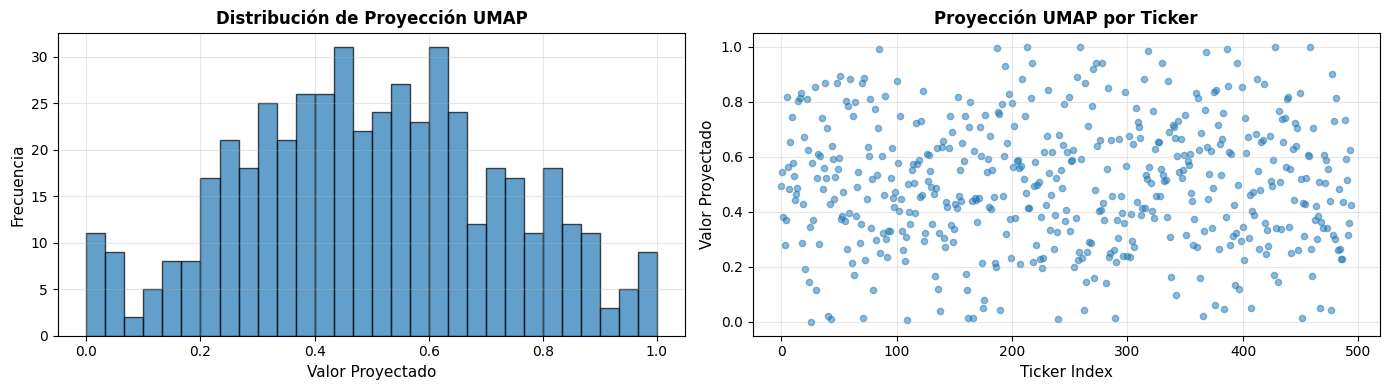

In [46]:
# =======================================================
# 📊 PASO 3: TOPOLOGICAL DATA ANALYSIS CON KEPLERMAPPER
# =======================================================

print("\n" + "="*80)
print("🔬 TOPOLOGICAL DATA ANALYSIS - KEPLERMAPPER")
print("="*80)

# Instalar umap-learn si no está disponible
try:
    import umap
except ImportError:
    print("📦 Instalando umap-learn...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "umap-learn"])
    import umap

from umap import UMAP

# Transponer para que cada fila sea un ticker
log_returns_T = log_returns.T.values

print(f"📊 Datos de entrada para TDA: {log_returns_T.shape}")
print(f"   (Tickers x Días): {log_returns_T.shape[0]} x {log_returns_T.shape[1]}")

# Inicializar KeplerMapper
mapper = km.KeplerMapper(verbose=1)

print("\n🔧 Aplicando reducción de dimensionalidad...")
print("   1️⃣ PCA (n_components=0.8) - Capturar 80% de varianza")
print("   2️⃣ UMAP (n_components=1) - Proyección a 1D")

# Proyección con PCA + UMAP
projected_data = mapper.fit_transform(
    log_returns_T,
    projection=[
        PCA(n_components=0.8, random_state=1),
        UMAP(n_components=1, random_state=1, n_jobs=-1)
    ]
)

print(f"\n✅ Proyección completada: {projected_data.shape}")
print(f"   Dimensión reducida: {projected_data.shape[1]}D")

# Visualizar distribución de la proyección
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.hist(projected_data[:, 0], bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Valor Proyectado', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.title('Distribución de Proyección UMAP', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(range(len(projected_data)), projected_data[:, 0], alpha=0.5, s=20)
plt.xlabel('Ticker Index', fontsize=11)
plt.ylabel('Valor Proyectado', fontsize=11)
plt.title('Proyección UMAP por Ticker', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*80)

In [47]:
projected_data

array([[0.49547827],
       [0.54367536],
       [0.3807477 ],
       [0.27860993],
       [0.37071124],
       [0.8152555 ],
       [0.5617202 ],
       [0.48165256],
       [0.6540635 ],
       [0.7430474 ],
       [0.5769579 ],
       [0.53126776],
       [0.44258782],
       [0.46384323],
       [0.48502988],
       [0.8013956 ],
       [0.81235844],
       [0.8320758 ],
       [0.28807846],
       [0.42970058],
       [0.6709353 ],
       [0.19225366],
       [0.81043833],
       [0.6241508 ],
       [0.1459018 ],
       [0.3445247 ],
       [0.        ],
       [0.575616  ],
       [0.37166664],
       [0.8545165 ],
       [0.11483352],
       [0.52213955],
       [0.6097282 ],
       [0.28300866],
       [0.60383326],
       [0.74162996],
       [0.48128188],
       [0.5608378 ],
       [0.86652154],
       [0.5231212 ],
       [0.7037369 ],
       [0.02035038],
       [0.42729923],
       [0.0114616 ],
       [0.6402661 ],
       [0.59311813],
       [0.4448764 ],
       [0.527

## Clustering

In [48]:
# =======================================================
# 📊 PASO 4: CLUSTERING CON DBSCAN (MÉTRICA DE CORRELACIÓN)
# =======================================================

print("\n" + "="*80)
print("🎯 CLUSTERING CON DBSCAN")
print("="*80)

print("🔧 Configuración:")
print("   📏 Métrica: Correlación")
print("   🎛️ Parámetros: eps=auto, min_samples=auto")

# Construir el grafo con DBSCAN usando métrica de correlación
graph = mapper.map(
    projected_data,
    log_returns_T,
    clusterer=DBSCAN(metric='correlation', n_jobs=-1),
    cover=km.Cover(n_cubes=10, perc_overlap=0.3)
)

print(f"\n✅ Grafo construido:")
print(f"   📊 Nodos: {len(graph['nodes'])}")
print(f"   🔗 Enlaces: {len(graph['links'])}")

# Analizar estructura del grafo
print(f"\n📋 Análisis de nodos:")

# Extraer clusters del grafo
node_clusters = {}
for node_id, node_members in graph['nodes'].items():
    node_clusters[node_id] = [available_tickers[i] for i in node_members]

# Mostrar información de clusters
cluster_sizes = [len(members) for members in node_clusters.values()]
print(f"   Número de clusters: {len(node_clusters)}")
print(f"   Tamaño promedio: {np.mean(cluster_sizes):.1f} tickers")
print(f"   Tamaño mínimo: {np.min(cluster_sizes)} tickers")
print(f"   Tamaño máximo: {np.max(cluster_sizes)} tickers")

# Mostrar distribución de tamaños
print(f"\n📊 Distribución de tamaños de clusters:")
size_distribution = pd.Series(cluster_sizes).value_counts().sort_index()
for size, count in size_distribution.items():
    print(f"   {size:3d} tickers: {count:3d} clusters")

print("="*80)


🎯 CLUSTERING CON DBSCAN
🔧 Configuración:
   📏 Métrica: Correlación
   🎛️ Parámetros: eps=auto, min_samples=auto
Mapping on data shaped (495, 500) using lens shaped (495, 1)

Creating 10 hypercubes.

Created 9 edges and 12 nodes in 0:00:00.189739.

✅ Grafo construido:
   📊 Nodos: 12
   🔗 Enlaces: 9

📋 Análisis de nodos:
   Número de clusters: 12
   Tamaño promedio: 50.8 tickers
   Tamaño mínimo: 7 tickers
   Tamaño máximo: 107 tickers

📊 Distribución de tamaños de clusters:
     7 tickers:   1 clusters
    10 tickers:   1 clusters
    17 tickers:   1 clusters
    26 tickers:   1 clusters
    28 tickers:   1 clusters
    44 tickers:   1 clusters
    57 tickers:   1 clusters
    64 tickers:   1 clusters
    77 tickers:   1 clusters
    84 tickers:   1 clusters
    88 tickers:   1 clusters
   107 tickers:   1 clusters

Created 9 edges and 12 nodes in 0:00:00.189739.

✅ Grafo construido:
   📊 Nodos: 12
   🔗 Enlaces: 9

📋 Análisis de nodos:
   Número de clusters: 12
   Tamaño promedio: 50.8

## Reducción de portafolio

In [49]:
# =======================================================
# 📊 PASO 5A: REDUCCIÓN DE PORTAFOLIO - SELECCIÓN DE REPRESENTANTES
# =======================================================

print("\n" + "="*80)
print("✂️  REDUCCIÓN DE PORTAFOLIO - SELECCIÓN DE REPRESENTANTES POR CLUSTER")
print("="*80)

def select_cluster_representatives(clusters_dict, metrics_dict, ticker_info, 
                                   n_per_cluster=1, selection_method='combined'):
    """
    Selecciona los tickers más representativos de cada cluster.
    
    Parámetros:
    -----------
    clusters_dict : dict
        {cluster_id: [lista de tickers]}
    metrics_dict : dict
        {ticker: {'sharpe_ratio': ..., 'volatility': ..., etc}}
    ticker_info : dict
        {ticker: {'market_cap': ..., 'sector': ..., etc}}
    n_per_cluster : int
        Número de tickers a seleccionar por cluster (default: 1)
    selection_method : str
        'sharpe' - Mejor Sharpe Ratio
        'market_cap' - Mayor capitalización
        'volatility' - Menor volatilidad
        'combined' - Combinación de Sharpe + Market Cap (RECOMENDADO)
    
    Returns:
    --------
    selected_tickers : list
        Lista de tickers seleccionados
    cluster_info : dict
        Información de selección por cluster
    """
    selected_tickers = []
    cluster_selection_info = {}
    
    print(f"🔧 Método de selección: {selection_method}")
    print(f"📊 Tickers por cluster: {n_per_cluster}")
    print(f"\n📋 Seleccionando representantes...")
    
    for cluster_id, tickers in clusters_dict.items():
        if len(tickers) == 0:
            continue
        
        # Calcular scores para cada ticker
        ticker_scores = []
        for ticker in tickers:
            metrics = metrics_dict.get(ticker, {})
            info = ticker_info.get(ticker, {})
            
            sharpe = metrics.get('sharpe_ratio', 0)
            volatility = metrics.get('volatility', 1)
            market_cap = info.get('market_cap', 0)
            
            if selection_method == 'sharpe':
                score = sharpe
            elif selection_method == 'market_cap':
                score = market_cap
            elif selection_method == 'volatility':
                score = -volatility  # Negativo porque queremos MENOR volatilidad
            elif selection_method == 'combined':
                # Normalizar y combinar (50% Sharpe, 50% Market Cap)
                # Usar ranking para evitar problemas de escala
                score = sharpe * 0.5 + (market_cap / 1e12) * 0.5 
            else:
                score = 0
            
            ticker_scores.append({
                'ticker': ticker,
                'score': score,
                'sharpe': sharpe,
                'volatility': volatility,
                'market_cap': market_cap
            })
        
        # Ordenar por score y seleccionar top N
        ticker_scores.sort(key=lambda x: x['score'], reverse=True)
        selected = ticker_scores[:n_per_cluster]
        
        # Guardar seleccionados
        for item in selected:
            selected_tickers.append(item['ticker'])
        
        # Guardar info del cluster
        cluster_selection_info[cluster_id] = {
            'total_tickers': len(tickers),
            'selected': [s['ticker'] for s in selected],
            'selected_info': selected
        }
        
        # Mostrar info de TODOS los seleccionados
        if len(selected) > 0:
            print(f"   Cluster {str(cluster_id):>10s} ({len(tickers):3d} tickers) → {len(selected)} seleccionado(s):")
            for i, sel_ticker in enumerate(selected, 1):
                print(f"      {i}. {sel_ticker['ticker']:5s} (Sharpe={sel_ticker['sharpe']:6.3f}, "
                      f"Vol={sel_ticker['volatility']*100:5.1f}%, MC=${sel_ticker['market_cap']/1e9:6.1f}B)")
    
    print(f"\n✅ Selección completada:")
    print(f"   📊 Tickers originales: {sum(len(t) for t in clusters_dict.values())}")
    print(f"   ✂️  Tickers seleccionados: {len(selected_tickers)}")
    print(f"   📉 Reducción: {(1 - len(selected_tickers)/sum(len(t) for t in clusters_dict.values()))*100:.1f}%")
    
    return selected_tickers, cluster_selection_info

# Preparar métricas en formato dict
financial_metrics_dict = metrics_df.to_dict('index')

# CONFIGURACIÓN DE REDUCCIÓN
N_REPRESENTATIVES = 1  # 🔧 CAMBIAR AQUÍ: 1, 2 o 3 tickers por cluster
SELECTION_METHOD = 'combined'  # 🔧 OPCIONES: 'sharpe', 'market_cap', 'volatility', 'combined'

# Aplicar selección de representantes
selected_tickers, cluster_info = select_cluster_representatives(
    node_clusters,
    financial_metrics_dict,
    ticker_info_db,
    n_per_cluster=N_REPRESENTATIVES,
    selection_method=SELECTION_METHOD
)

# Crear clusters reducidos (solo con representantes)
reduced_clusters = {
    cluster_id: info['selected'] 
    for cluster_id, info in cluster_info.items()
}

print("\n" + "="*80)


✂️  REDUCCIÓN DE PORTAFOLIO - SELECCIÓN DE REPRESENTANTES POR CLUSTER
🔧 Método de selección: combined
📊 Tickers por cluster: 1

📋 Seleccionando representantes...
   Cluster cube0_cluster0 ( 26 tickers) → 1 seleccionado(s):
      1. WELL  (Sharpe= 0.349, Vol= 26.4%, MC=$  47.9B)
   Cluster cube1_cluster0 ( 28 tickers) → 1 seleccionado(s):
      1. PHM   (Sharpe= 1.034, Vol= 37.7%, MC=$  22.0B)
   Cluster cube2_cluster0 ( 64 tickers) → 1 seleccionado(s):
      1. V     (Sharpe= 0.487, Vol= 24.5%, MC=$ 527.3B)
   Cluster cube3_cluster0 ( 77 tickers) → 1 seleccionado(s):
      1. CTAS  (Sharpe= 0.915, Vol= 23.5%, MC=$  15.0B)
   Cluster cube4_cluster0 ( 84 tickers) → 1 seleccionado(s):
      1. FICO  (Sharpe= 1.399, Vol= 40.3%, MC=$  28.8B)
   Cluster cube4_cluster1 ( 10 tickers) → 1 seleccionado(s):
      1. CAH   (Sharpe= 1.606, Vol= 24.3%, MC=$  24.1B)
   Cluster cube5_cluster0 (107 tickers) → 1 seleccionado(s):
      1. AAPL  (Sharpe= 0.262, Vol= 29.1%, MC=$2966.4B)
   Cluster cube6_c

In [50]:
# =======================================================
# 📊 PASO 5B: VISUALIZACIÓN DEL GRAFO TOPOLÓGICO
# =======================================================

print("\n" + "="*80)
print("🎨 GENERANDO VISUALIZACIÓN DEL GRAFO")
print("="*80)

# Crear visualización HTML del grafo
html_output = mapper.visualize(
    graph,
    path_html="mapper_portfolio_tda_500_red.html",
    title="Portfolio Construction - Topological Data Analysis",
    custom_tooltips=np.array([f"{ticker}" for ticker in available_tickers])
)

print("✅ Visualización guardada: 'mapper_portfolio_tda_500_red.html'")
print("   Abre este archivo en tu navegador para explorar el grafo interactivo")
print("="*80)


🎨 GENERANDO VISUALIZACIÓN DEL GRAFO
Wrote visualization to: mapper_portfolio_tda_500_red.html
✅ Visualización guardada: 'mapper_portfolio_tda_500_red.html'
   Abre este archivo en tu navegador para explorar el grafo interactivo


# Portafolio

In [51]:
# =======================================================
# 📊 PASO 6: CONSTRUCCIÓN DE PORTAFOLIO REDUCIDO - EQUAL CLUSTERS WEIGHTING
# =======================================================

print("\n" + "="*80)
print("💼 CONSTRUCCIÓN DE PORTAFOLIO REDUCIDO - EQUAL CLUSTERS WEIGHTING")
print("="*80)

def weight_distribution(clustered_symbols):
    """
    Asigna pesos iguales entre clusters y divide equitativamente dentro de cada cluster.
    
    Parámetros:
    -----------
    clustered_symbols : dict
        Diccionario con {cluster_id: [lista de símbolos]}
    
    Returns:
    --------
    weights : dict
        Diccionario con {símbolo: peso}
    """
    weights = {}
    num_clusters = len(clustered_symbols)
    
    if num_clusters == 0:
        return weights
    
    for cluster_id, symbols in clustered_symbols.items():
        if len(symbols) == 0:
            continue
            
        # Peso igual por cluster
        cluster_weight = 1.0 / num_clusters
        
        # Dividir peso del cluster entre sus símbolos
        symbol_weight = cluster_weight / len(symbols)
        
        for symbol in symbols:
            weights[symbol] = symbol_weight
    
    return weights

# Aplicar la distribución de pesos AL PORTAFOLIO REDUCIDO
portfolio_weights = weight_distribution(reduced_clusters)

print(f"🎯 COMPARACIÓN DE PORTAFOLIOS:")
print(f"   📊 Portafolio Original: {sum(len(c) for c in node_clusters.values())} tickers")
print(f"   ✂️  Portafolio Reducido: {len(portfolio_weights)} tickers")
print(f"   📉 Reducción: {(1 - len(portfolio_weights)/sum(len(c) for c in node_clusters.values()))*100:.1f}%")

print(f"✅ Pesos calculados para {len(portfolio_weights)} símbolos")
print(f"   Número de clusters: {len(node_clusters)}")
print(f"   Suma total de pesos: {sum(portfolio_weights.values()):.6f}")

# Estadísticas de pesos
weights_values = list(portfolio_weights.values())
print(f"\n📊 Estadísticas de pesos:")
print(f"   Peso promedio: {np.mean(weights_values):.4%}")
print(f"   Peso mínimo: {np.min(weights_values):.4%}")
print(f"   Peso máximo: {np.max(weights_values):.4%}")
print(f"   Desv. estándar: {np.std(weights_values):.4%}")

# Mostrar top 10 pesos
print(f"\n🔝 Top  tickers por peso:")
sorted_weights = sorted(portfolio_weights.items(), key=lambda x: x[1], reverse=True)
for i, (ticker, weight) in enumerate(sorted_weights, 1):
    cluster_id = [cid for cid, members in node_clusters.items() if ticker in members][0]
    cluster_size = len(node_clusters[cluster_id])
    print(f"   {i:2d}. {ticker:5s}: {weight:7.4%} (Cluster {cluster_id}, size={cluster_size})")

print("="*80)


💼 CONSTRUCCIÓN DE PORTAFOLIO REDUCIDO - EQUAL CLUSTERS WEIGHTING
🎯 COMPARACIÓN DE PORTAFOLIOS:
   📊 Portafolio Original: 609 tickers
   ✂️  Portafolio Reducido: 12 tickers
   📉 Reducción: 98.0%
✅ Pesos calculados para 12 símbolos
   Número de clusters: 12
   Suma total de pesos: 1.000000

📊 Estadísticas de pesos:
   Peso promedio: 8.3333%
   Peso mínimo: 8.3333%
   Peso máximo: 8.3333%
   Desv. estándar: 0.0000%

🔝 Top  tickers por peso:
    1. WELL : 8.3333% (Cluster cube0_cluster0, size=26)
    2. PHM  : 8.3333% (Cluster cube1_cluster0, size=28)
    3. V    : 8.3333% (Cluster cube2_cluster0, size=64)
    4. CTAS : 8.3333% (Cluster cube3_cluster0, size=77)
    5. FICO : 8.3333% (Cluster cube4_cluster0, size=84)
    6. CAH  : 8.3333% (Cluster cube4_cluster1, size=10)
    7. AAPL : 8.3333% (Cluster cube5_cluster0, size=107)
    8. GOOG : 8.3333% (Cluster cube5_cluster0, size=107)
    9. MPC  : 8.3333% (Cluster cube6_cluster0, size=88)
   10. ACGL : 8.3333% (Cluster cube7_cluster0, size

## redistribución de pesos

In [52]:
# =======================================================
# 🔍 DIAGNÓSTICO: VERIFICAR CLUSTERS Y TICKERS FALTANTES
# =======================================================

print("\n" + "="*80)
print("🔍 DIAGNÓSTICO: Clusters vs Tickers en Portafolio")
print("="*80)

# 1. Contar clusters
num_clusters = len(node_clusters)
print(f"\n📊 Número de clusters en node_clusters: {num_clusters}")

# 2. Contar tickers en portfolio_weights
num_tickers_portfolio = len(portfolio_weights)
print(f"📊 Número de tickers en portfolio_weights: {num_tickers_portfolio}")

# 3. Verificar suma de pesos
suma_pesos = sum(portfolio_weights.values())
print(f"📊 Suma de pesos en portfolio_weights: {suma_pesos:.6f}")
print(f"   {'✅ Correcto' if abs(suma_pesos - 1.0) < 0.001 else '❌ PROBLEMA: No suma 1.0!'}")

# 4. Mostrar peso individual esperado vs real
peso_esperado = 1.0 / num_clusters
peso_real_promedio = sum(portfolio_weights.values()) / len(portfolio_weights)
print(f"\n📊 Peso esperado por ticker (1/{num_clusters}): {peso_esperado:.6f} ({peso_esperado*100:.2f}%)")
print(f"📊 Peso real promedio: {peso_real_promedio:.6f} ({peso_real_promedio*100:.2f}%)")

# 5. Identificar clusters sin ticker
clusters_con_ticker = set()
for ticker in portfolio_weights.keys():
    for cid, members in node_clusters.items():
        if ticker in members:
            clusters_con_ticker.add(cid)
            break

clusters_sin_ticker = set(node_clusters.keys()) - clusters_con_ticker
print(f"\n📊 Clusters con ticker asignado: {len(clusters_con_ticker)}/{num_clusters}")
print(f"📊 Clusters SIN ticker asignado: {len(clusters_sin_ticker)}")

if clusters_sin_ticker:
    print(f"\n⚠️  CLUSTERS FALTANTES:")
    for cid in sorted(clusters_sin_ticker):
        print(f"   Cluster {cid}: {len(node_clusters[cid])} miembros - {list(node_clusters[cid])[:3]}...")

# 6. Verificar si los tickers del portafolio están en tickers_data
tickers_faltantes_en_data = [t for t in portfolio_weights.keys() if t not in tickers_data.columns]
if tickers_faltantes_en_data:
    print(f"\n⚠️  TICKERS EN PORTFOLIO PERO NO EN tickers_data:")
    for t in tickers_faltantes_en_data:
        print(f"   {t}")

print("\n" + "="*80)
print("💡 RECOMENDACIÓN:")
if clusters_sin_ticker:
    print("   Hay clusters sin ticker asignado. Esto causa que el portafolio no sume 100%.")
    print("   Solución: Ajustar pesos para que sumen exactamente 1.0")
    print(f"   Peso que falta: {(1.0 - suma_pesos)*100:.2f}%")
elif suma_pesos < 0.999:
    print(f"   Los pesos solo suman {suma_pesos:.4f} en lugar de 1.0")
    print(f"   Falta: {(1.0 - suma_pesos)*100:.2f}%")
else:
    print("   ✅ Todo correcto: Todos los clusters tienen ticker y los pesos suman 1.0")
print("="*80)


🔍 DIAGNÓSTICO: Clusters vs Tickers en Portafolio

📊 Número de clusters en node_clusters: 12
📊 Número de tickers en portfolio_weights: 12
📊 Suma de pesos en portfolio_weights: 1.000000
   ✅ Correcto

📊 Peso esperado por ticker (1/12): 0.083333 (8.33%)
📊 Peso real promedio: 0.083333 (8.33%)

📊 Clusters con ticker asignado: 11/12
📊 Clusters SIN ticker asignado: 1

⚠️  CLUSTERS FALTANTES:
   Cluster cube9_cluster0: 17 miembros - ['BAC', 'BK', 'C']...

💡 RECOMENDACIÓN:
   Hay clusters sin ticker asignado. Esto causa que el portafolio no sume 100%.
   Solución: Ajustar pesos para que sumen exactamente 1.0
   Peso que falta: 0.00%


In [53]:
# =======================================================
# 🔧 CORRECCIÓN: NORMALIZAR PESOS PARA QUE SUMEN 1.0
# =======================================================

print("\n" + "="*80)
print("🔧 CORRECCIÓN: Normalizando pesos del portafolio")
print("="*80)

# Verificar suma actual
suma_original = sum(portfolio_weights.values())
print(f"\n📊 Suma de pesos ANTES de corrección: {suma_original:.6f}")

if abs(suma_original - 1.0) > 0.001:
    print(f"   ⚠️  Los pesos no suman 1.0, normalizando...")
    
    # Normalizar pesos para que sumen exactamente 1.0
    portfolio_weights_corrected = {
        ticker: peso / suma_original 
        for ticker, peso in portfolio_weights.items()
    }
    
    # Verificar
    suma_corregida = sum(portfolio_weights_corrected.values())
    print(f"📊 Suma de pesos DESPUÉS de corrección: {suma_corregida:.10f}")
    print(f"   ✅ Correcto!")
    
    # Mostrar diferencia
    print(f"\n📊 Comparación de pesos:")
    print(f"{'Ticker':<10} {'Peso Original (%)':<20} {'Peso Corregido (%)':<20} {'Diferencia':<15}")
    print("-"*70)
    for ticker in sorted(portfolio_weights.keys()):
        peso_orig = portfolio_weights[ticker] * 100
        peso_corr = portfolio_weights_corrected[ticker] * 100
        diff = peso_corr - peso_orig
        print(f"{ticker:<10} {peso_orig:>18.4f}% {peso_corr:>19.4f}% {diff:>+14.4f}%")
    
    # Reemplazar portfolio_weights con la versión corregida
    portfolio_weights = portfolio_weights_corrected
    print(f"\n✅ portfolio_weights actualizado con pesos normalizados")
    
else:
    print(f"   ✅ Los pesos ya suman 1.0, no se requiere corrección")

print("="*80)


🔧 CORRECCIÓN: Normalizando pesos del portafolio

📊 Suma de pesos ANTES de corrección: 1.000000
   ✅ Los pesos ya suman 1.0, no se requiere corrección


## Back testing

In [54]:
# =======================================================
# 📊 PASO 7: BACKTESTING - SIMULACIÓN DEL PORTAFOLIO
# =======================================================

print("\n" + "="*80)
print("📈 BACKTESTING - SIMULACIÓN DEL PORTAFOLIO TDA")
print("="*80)

# Usar datos del período de análisis
backtest_data = tickers_data[list(portfolio_weights.keys())].copy()

print(f"📊 Datos para backtest:")
print(f"   Tickers en portafolio: {len(portfolio_weights)}")
print(f"   Período: {backtest_data.index[0].strftime('%Y-%m-%d')} a {backtest_data.index[-1].strftime('%Y-%m-%d')}")
print(f"   Días de trading: {len(backtest_data)}")

# Calcular retornos diarios
daily_returns = backtest_data.pct_change().dropna()

# Calcular retorno del portafolio
weights_array = np.array([portfolio_weights[ticker] for ticker in daily_returns.columns])
portfolio_daily_returns = (daily_returns * weights_array).sum(axis=1)

# Calcular valor acumulado del portafolio (comenzando en 1)
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()

# Calcular SPY para comparación
spy_returns_analysis = SPY_analysis['SPY'].pct_change().dropna()
spy_cumulative = (1 + spy_returns_analysis).cumprod()

# Alinear índices
common_dates = portfolio_cumulative.index.intersection(spy_cumulative.index)
portfolio_cumulative = portfolio_cumulative[common_dates]
spy_cumulative = spy_cumulative[common_dates]

print(f"\n✅ Backtest completado")
print(f"   Valor final portafolio TDA: {portfolio_cumulative.iloc[-1]:.4f}")
print(f"   Valor final SPY: {spy_cumulative.iloc[-1]:.4f}")
print(f"   Diferencia: {((portfolio_cumulative.iloc[-1] / spy_cumulative.iloc[-1]) - 1) * 100:+.2f}%")

print("="*80)


📈 BACKTESTING - SIMULACIÓN DEL PORTAFOLIO TDA
📊 Datos para backtest:
   Tickers en portafolio: 12
   Período: 2022-01-03 a 2023-12-29
   Días de trading: 501

✅ Backtest completado
   Valor final portafolio TDA: 1.5816
   Valor final SPY: 1.0265
   Diferencia: +54.07%


In [55]:
# =======================================================
# 📊 PASO 8: MÉTRICAS DE PERFORMANCE
# =======================================================

print("\n" + "="*80)
print("📊 MÉTRICAS DE PERFORMANCE")
print("="*80)

def calculate_portfolio_metrics(returns, cumulative_value, name="Portfolio"):
    """Calcula métricas de performance de un portafolio"""
    
    # Retorno total
    total_return = (cumulative_value.iloc[-1] - 1) * 100
    
    # Retorno anualizado
    n_years = len(returns) / 252
    annualized_return = ((cumulative_value.iloc[-1]) ** (1/n_years) - 1) * 100
    
    # Volatilidad anualizada
    volatility = returns.std() * np.sqrt(252) * 100
    
    # Sharpe Ratio (asumiendo rf=0)
    sharpe = annualized_return / volatility if volatility > 0 else 0
    
    # Maximum Drawdown
    running_max = cumulative_value.cummax()
    drawdown = (cumulative_value - running_max) / running_max
    max_drawdown = drawdown.min() * 100
    
    # Calmar Ratio
    calmar = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # Winning days percentage
    winning_days = (returns > 0).sum() / len(returns) * 100
    
    return {
        'name': name,
        'total_return': total_return,
        'annualized_return': annualized_return,
        'volatility': volatility,
        'sharpe_ratio': sharpe,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar,
        'winning_days_pct': winning_days
    }

# Calcular métricas para portafolio TDA
tda_metrics = calculate_portfolio_metrics(
    portfolio_daily_returns, 
    portfolio_cumulative, 
    "TDA Portfolio"
)

# Calcular métricas para SPY
spy_metrics = calculate_portfolio_metrics(
    spy_returns_analysis[common_dates], 
    spy_cumulative, 
    "SPY Benchmark"
)

# Calcular Beta del portafolio vs SPY
covariance = np.cov(portfolio_daily_returns, spy_returns_analysis[common_dates])[0, 1]
spy_variance = spy_returns_analysis[common_dates].var()
beta = covariance / spy_variance if spy_variance > 0 else 0

# Crear tabla comparativa
metrics_comparison = pd.DataFrame([tda_metrics, spy_metrics])
metrics_comparison = metrics_comparison.set_index('name')

print("\n📋 TABLA COMPARATIVA DE MÉTRICAS:")
print("="*80)
display(metrics_comparison.round(4))

print(f"\n📊 MÉTRICAS ADICIONALES:")
print(f"   Beta (vs SPY): {beta:.4f}")
print(f"   Alpha anualizado: {(tda_metrics['annualized_return'] - beta * spy_metrics['annualized_return']):.2f}%")
print(f"   Information Ratio: {((tda_metrics['annualized_return'] - spy_metrics['annualized_return']) / (portfolio_daily_returns - spy_returns_analysis[common_dates]).std() / np.sqrt(252) * 100):.4f}")

print("\n" + "="*80)
print("🎯 RESUMEN:")
print("="*80)

outperformance = tda_metrics['annualized_return'] - spy_metrics['annualized_return']
print(f"{'Retorno anualizado:':<25} TDA: {tda_metrics['annualized_return']:>7.2f}%  |  SPY: {spy_metrics['annualized_return']:>7.2f}%  |  Diferencia: {outperformance:>+7.2f}%")
print(f"{'Sharpe Ratio:':<25} TDA: {tda_metrics['sharpe_ratio']:>7.4f}  |  SPY: {spy_metrics['sharpe_ratio']:>7.4f}  |  Diferencia: {tda_metrics['sharpe_ratio'] - spy_metrics['sharpe_ratio']:>+7.4f}")
print(f"{'Max Drawdown:':<25} TDA: {tda_metrics['max_drawdown']:>7.2f}%  |  SPY: {spy_metrics['max_drawdown']:>7.2f}%  |  Diferencia: {tda_metrics['max_drawdown'] - spy_metrics['max_drawdown']:>+7.2f}%")
print(f"{'Volatilidad:':<25} TDA: {tda_metrics['volatility']:>7.2f}%  |  SPY: {spy_metrics['volatility']:>7.2f}%  |  Diferencia: {tda_metrics['volatility'] - spy_metrics['volatility']:>+7.2f}%")

print("="*80)


📊 MÉTRICAS DE PERFORMANCE

📋 TABLA COMPARATIVA DE MÉTRICAS:


,total_return,annualized_return,volatility,sharpe_ratio,max_drawdown,calmar_ratio,winning_days_pct
name,,,,,,,
TDA Portfolio,58.1552,25.9906,18.9346,1.3727,-15.3105,1.6976,55.6
SPY Benchmark,2.6485,1.3262,19.5273,0.0679,-24.4711,0.0542,49.6



📊 MÉTRICAS ADICIONALES:
   Beta (vs SPY): 0.9072
   Alpha anualizado: 24.79%
   Information Ratio: 35611.1505

🎯 RESUMEN:
Retorno anualizado:       TDA:   25.99%  |  SPY:    1.33%  |  Diferencia:  +24.66%
Sharpe Ratio:             TDA:  1.3727  |  SPY:  0.0679  |  Diferencia: +1.3047
Max Drawdown:             TDA:  -15.31%  |  SPY:  -24.47%  |  Diferencia:   +9.16%
Volatilidad:              TDA:   18.93%  |  SPY:   19.53%  |  Diferencia:   -0.59%



📊 GENERANDO VISUALIZACIONES


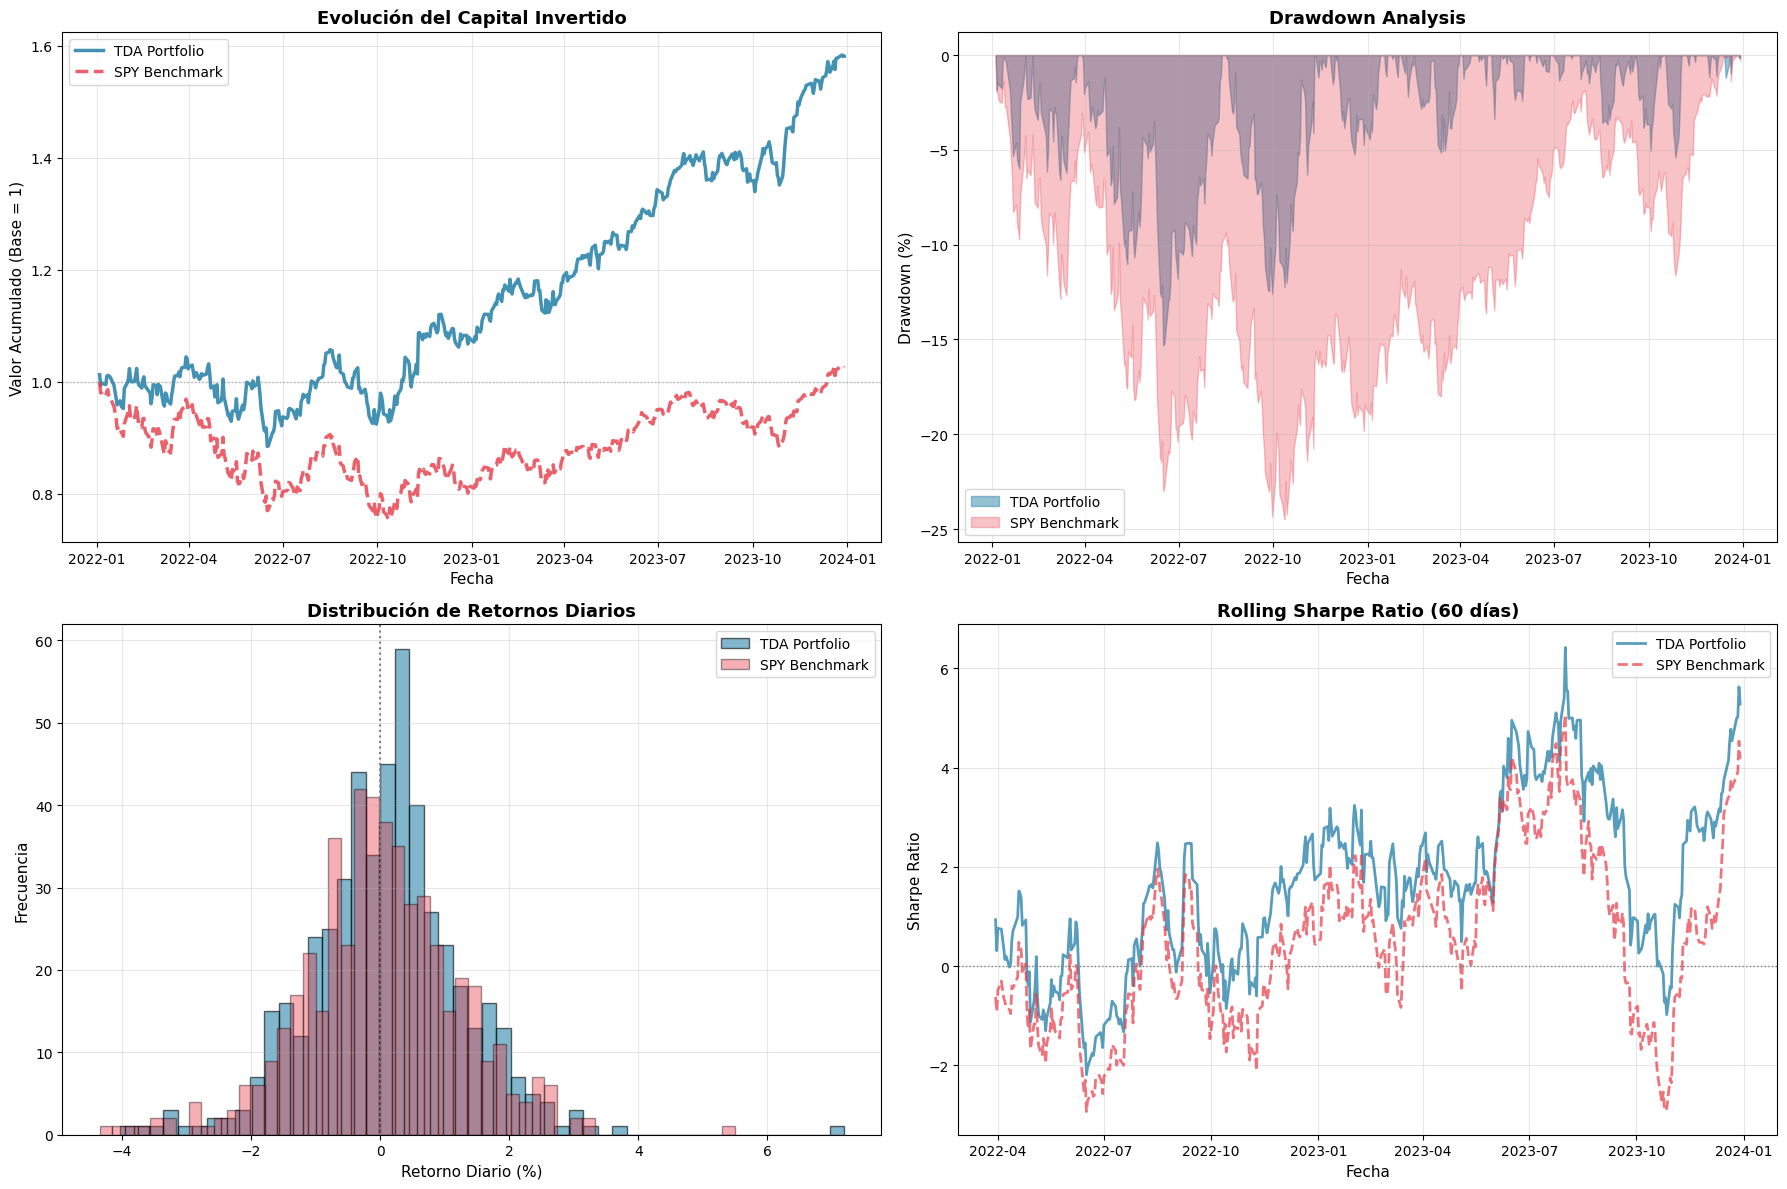

✅ Visualizaciones generadas


In [56]:
# =======================================================
# 📊 PASO 9: VISUALIZACIONES
# =======================================================

print("\n" + "="*80)
print("📊 GENERANDO VISUALIZACIONES")
print("="*80)

# Crear figura con múltiples subplots
fig = plt.figure(figsize=(18, 12))

# 1. Evolución del valor del portafolio
ax1 = plt.subplot(2, 2, 1)
ax1.plot(portfolio_cumulative.index, portfolio_cumulative.values, 
         linewidth=2.5, label='TDA Portfolio', color='#2E86AB', alpha=0.9)
ax1.plot(spy_cumulative.index, spy_cumulative.values, 
         linewidth=2.5, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.8)
ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_title('Evolución del Capital Invertido', fontsize=13, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Valor Acumulado (Base = 1)', fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# 2. Drawdown
ax2 = plt.subplot(2, 2, 2)
tda_running_max = portfolio_cumulative.cummax()
tda_drawdown = (portfolio_cumulative - tda_running_max) / tda_running_max * 100

spy_running_max = spy_cumulative.cummax()
spy_drawdown = (spy_cumulative - spy_running_max) / spy_running_max * 100

ax2.fill_between(tda_drawdown.index, tda_drawdown.values, 0, 
                  alpha=0.5, color='#2E86AB', label='TDA Portfolio')
ax2.fill_between(spy_drawdown.index, spy_drawdown.values, 0, 
                  alpha=0.3, color='#E63946', label='SPY Benchmark')
ax2.set_title('Drawdown Analysis', fontsize=13, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)

# 3. Distribución de retornos diarios
ax3 = plt.subplot(2, 2, 3)
ax3.hist(portfolio_daily_returns * 100, bins=50, alpha=0.6, 
         color='#2E86AB', edgecolor='black', label='TDA Portfolio')
ax3.hist(spy_returns_analysis[common_dates] * 100, bins=50, alpha=0.4, 
         color='#E63946', edgecolor='black', label='SPY Benchmark')
ax3.axvline(x=0, color='gray', linestyle=':', linewidth=1.5)
ax3.set_title('Distribución de Retornos Diarios', fontsize=13, fontweight='bold')
ax3.set_xlabel('Retorno Diario (%)', fontsize=11)
ax3.set_ylabel('Frecuencia', fontsize=11)
ax3.legend(fontsize=10, loc='best')
ax3.grid(True, alpha=0.3)

# 4. Rolling Sharpe Ratio (ventana de 60 días)
ax4 = plt.subplot(2, 2, 4)
window = 60
tda_rolling_sharpe = portfolio_daily_returns.rolling(window).mean() / portfolio_daily_returns.rolling(window).std() * np.sqrt(252)
spy_rolling_sharpe = spy_returns_analysis[common_dates].rolling(window).mean() / spy_returns_analysis[common_dates].rolling(window).std() * np.sqrt(252)

ax4.plot(tda_rolling_sharpe.index, tda_rolling_sharpe.values, 
         linewidth=2, label='TDA Portfolio', color='#2E86AB', alpha=0.8)
ax4.plot(spy_rolling_sharpe.index, spy_rolling_sharpe.values, 
         linewidth=2, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.7)
ax4.axhline(y=0, color='gray', linestyle=':', linewidth=1)
ax4.set_title(f'Rolling Sharpe Ratio ({window} días)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Fecha', fontsize=11)
ax4.set_ylabel('Sharpe Ratio', fontsize=11)
ax4.legend(fontsize=10, loc='best')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")
print("="*80)


⚖️  ANÁLISIS DE DISTRIBUCIÓN DE PESOS


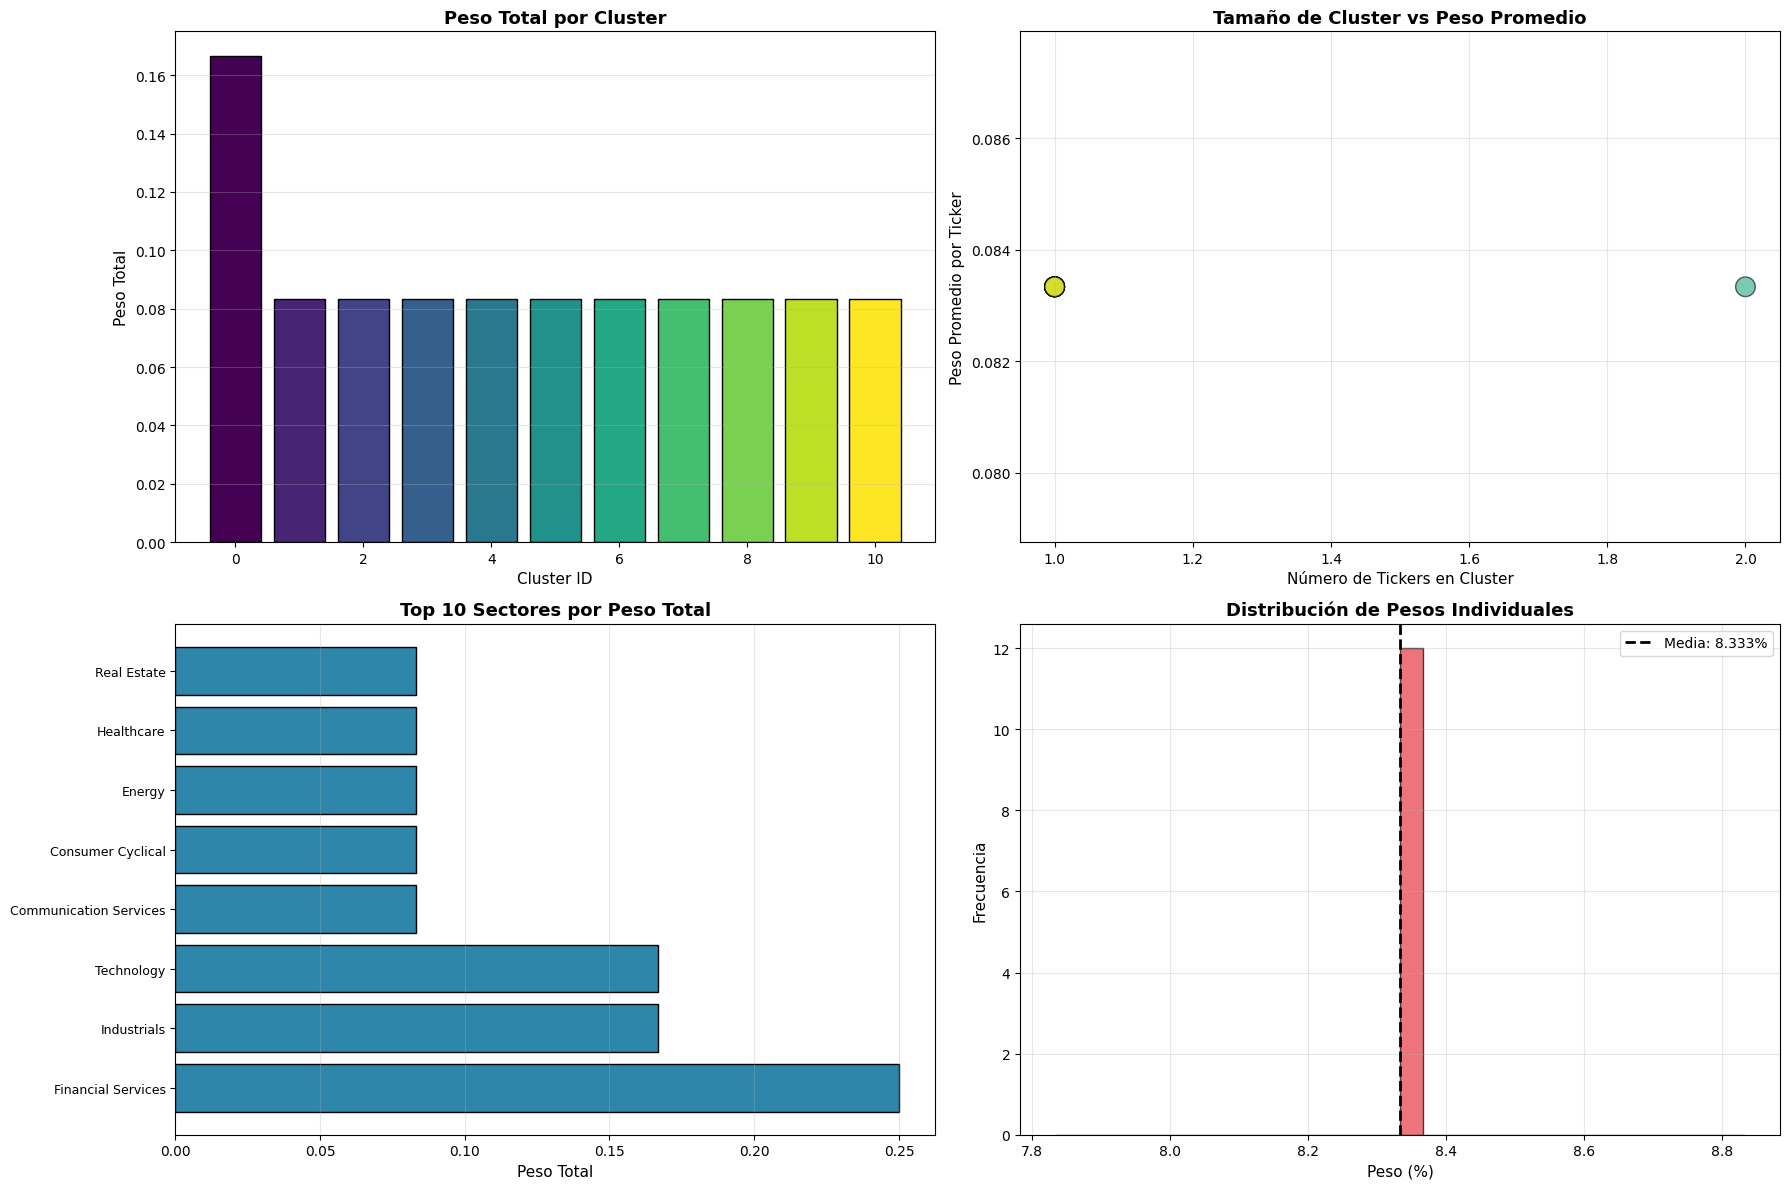


📊 EXPOSICIÓN POR SECTOR:
Financial Services            :  25.00% (  3 tickers, avg=8.333%)
Industrials                   :  16.67% (  2 tickers, avg=8.333%)
Technology                    :  16.67% (  2 tickers, avg=8.333%)
Communication Services        :   8.33% (  1 tickers, avg=8.333%)
Consumer Cyclical             :   8.33% (  1 tickers, avg=8.333%)
Energy                        :   8.33% (  1 tickers, avg=8.333%)
Healthcare                    :   8.33% (  1 tickers, avg=8.333%)
Real Estate                   :   8.33% (  1 tickers, avg=8.333%)


In [57]:
# =======================================================
# 📊 PASO 10: ANÁLISIS DE DISTRIBUCIÓN DE PESOS
# =======================================================

print("\n" + "="*80)
print("⚖️  ANÁLISIS DE DISTRIBUCIÓN DE PESOS")
print("="*80)

# Crear DataFrame con información de clusters y pesos
weight_analysis = []
for ticker, weight in portfolio_weights.items():
    # Encontrar cluster del ticker
    cluster_id = [cid for cid, members in node_clusters.items() if ticker in members][0]
    cluster_size = len(node_clusters[cluster_id])
    
    weight_analysis.append({
        'ticker': ticker,
        'weight': weight,
        'cluster_id': cluster_id,
        'cluster_size': cluster_size,
        'sector': ticker_info_db.get(ticker, {}).get('sector', 'Unknown'),
        'market_cap': ticker_info_db.get(ticker, {}).get('market_cap', 0)
    })

weight_df = pd.DataFrame(weight_analysis)

# Visualización de pesos
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Distribución de pesos por cluster
ax1 = axes[0, 0]
cluster_weights = weight_df.groupby('cluster_id')['weight'].sum().sort_values(ascending=False)
colors_clusters = plt.cm.viridis(np.linspace(0, 1, len(cluster_weights)))
ax1.bar(range(len(cluster_weights)), cluster_weights.values, color=colors_clusters, edgecolor='black')
ax1.set_title('Peso Total por Cluster', fontsize=13, fontweight='bold')
ax1.set_xlabel('Cluster ID', fontsize=11)
ax1.set_ylabel('Peso Total', fontsize=11)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Tamaño de clusters vs peso promedio
ax2 = axes[0, 1]
cluster_analysis_viz = weight_df.groupby('cluster_id').agg({
    'weight': 'mean',
    'ticker': 'count'
}).rename(columns={'ticker': 'size'})
scatter = ax2.scatter(cluster_analysis_viz['size'], cluster_analysis_viz['weight'], 
                     s=200, alpha=0.6, c=range(len(cluster_analysis_viz)), cmap='viridis', edgecolors='black')
ax2.set_title('Tamaño de Cluster vs Peso Promedio', fontsize=13, fontweight='bold')
ax2.set_xlabel('Número de Tickers en Cluster', fontsize=11)
ax2.set_ylabel('Peso Promedio por Ticker', fontsize=11)
ax2.grid(True, alpha=0.3)

# 3. Distribución de pesos por sector
ax3 = axes[1, 0]
sector_weights = weight_df.groupby('sector')['weight'].sum().sort_values(ascending=False)[:10]
ax3.barh(range(len(sector_weights)), sector_weights.values, color='#2E86AB', edgecolor='black')
ax3.set_yticks(range(len(sector_weights)))
ax3.set_yticklabels(sector_weights.index, fontsize=9)
ax3.set_title('Top 10 Sectores por Peso Total', fontsize=13, fontweight='bold')
ax3.set_xlabel('Peso Total', fontsize=11)
ax3.grid(True, alpha=0.3, axis='x')

# 4. Histograma de pesos individuales
ax4 = axes[1, 1]
ax4.hist(weight_df['weight'] * 100, bins=30, color='#E63946', edgecolor='black', alpha=0.7)
ax4.axvline(x=weight_df['weight'].mean() * 100, color='black', linestyle='--', linewidth=2, label=f'Media: {weight_df["weight"].mean()*100:.3f}%')
ax4.set_title('Distribución de Pesos Individuales', fontsize=13, fontweight='bold')
ax4.set_xlabel('Peso (%)', fontsize=11)
ax4.set_ylabel('Frecuencia', fontsize=11)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar estadísticas por sector
print("\n📊 EXPOSICIÓN POR SECTOR:")
print("="*80)
sector_exposure = weight_df.groupby('sector').agg({
    'weight': 'sum',
    'ticker': 'count'
}).rename(columns={'ticker': 'num_tickers', 'weight': 'total_weight'})
sector_exposure['num_tickers'] = sector_exposure['num_tickers'].astype(int)
sector_exposure['avg_weight'] = sector_exposure['total_weight'] / sector_exposure['num_tickers']
sector_exposure = sector_exposure.sort_values('total_weight', ascending=False)

for sector, row in sector_exposure.head(10).iterrows():
    print(f"{sector:30s}: {row['total_weight']*100:6.2f}% ({int(row['num_tickers']):3d} tickers, avg={row['avg_weight']*100:.3f}%)")

print("="*80)

In [58]:
# =======================================================
# 📊 PASO 11: VALIDACIÓN OUT-OF-SAMPLE
# =======================================================

print("\n" + "="*80)
print("🔍 VALIDACIÓN OUT-OF-SAMPLE")
print("="*80)

# Usar los mismos pesos calculados en el período de análisis
# pero aplicarlos al período de validación
validation_tickers = [t for t in portfolio_weights.keys() if t in validation_data.columns]

print(f"📊 Configuración:")
print(f"   Tickers disponibles en validación: {len(validation_tickers)}/{len(portfolio_weights)}")
print(f"   Período: {validation_data.index[0].strftime('%Y-%m-%d')} a {validation_data.index[-1].strftime('%Y-%m-%d')}")

# Ajustar pesos para tickers disponibles (renormalizar)
adjusted_weights = {t: portfolio_weights[t] for t in validation_tickers}
total_weight = sum(adjusted_weights.values())
adjusted_weights = {t: w/total_weight for t, w in adjusted_weights.items()}

print(f"   Suma de pesos ajustados: {sum(adjusted_weights.values()):.6f}")

# Calcular retornos en validación
validation_subset = validation_data[validation_tickers].copy()
validation_returns = validation_subset.pct_change().dropna()

# Retorno del portafolio en validación
weights_array_val = np.array([adjusted_weights[ticker] for ticker in validation_returns.columns])
portfolio_val_returns = (validation_returns * weights_array_val).sum(axis=1)

# Valor acumulado
portfolio_val_cumulative = (1 + portfolio_val_returns).cumprod()

# SPY en validación
spy_val_returns = SPY_validation['SPY'].pct_change().dropna()
spy_val_cumulative = (1 + spy_val_returns).cumprod()

# Alinear fechas
common_dates_val = portfolio_val_cumulative.index.intersection(spy_val_cumulative.index)
portfolio_val_cumulative = portfolio_val_cumulative[common_dates_val]
spy_val_cumulative = spy_val_cumulative[common_dates_val]
portfolio_val_returns = portfolio_val_returns[common_dates_val]
spy_val_returns = spy_val_returns[common_dates_val]

# Calcular métricas
tda_val_metrics = calculate_portfolio_metrics(
    portfolio_val_returns, 
    portfolio_val_cumulative, 
    "TDA Portfolio (OOS)"
)

spy_val_metrics = calculate_portfolio_metrics(
    spy_val_returns, 
    spy_val_cumulative, 
    "SPY Benchmark (OOS)"
)

# Crear tabla comparativa
val_comparison = pd.DataFrame([tda_val_metrics, spy_val_metrics])
val_comparison = val_comparison.set_index('name')

print("\n📋 MÉTRICAS OUT-OF-SAMPLE:")
print("="*80)
display(val_comparison.round(4))

print("\n🎯 COMPARACIÓN ANÁLISIS vs VALIDACIÓN:")
print("="*80)
print(f"{'Métrica':<30} {'In-Sample':<15} {'Out-of-Sample':<15} {'Diferencia':<15}")
print("-"*80)
print(f"{'Retorno Anualizado (TDA):':<30} {tda_metrics['annualized_return']:>12.2f}%  {tda_val_metrics['annualized_return']:>12.2f}%  {tda_val_metrics['annualized_return'] - tda_metrics['annualized_return']:>+12.2f}%")
print(f"{'Sharpe Ratio (TDA):':<30} {tda_metrics['sharpe_ratio']:>14.4f}  {tda_val_metrics['sharpe_ratio']:>14.4f}  {tda_val_metrics['sharpe_ratio'] - tda_metrics['sharpe_ratio']:>+14.4f}")
print(f"{'Max Drawdown (TDA):':<30} {tda_metrics['max_drawdown']:>12.2f}%  {tda_val_metrics['max_drawdown']:>12.2f}%  {tda_val_metrics['max_drawdown'] - tda_metrics['max_drawdown']:>+12.2f}%")
print(f"{'Volatilidad (TDA):':<30} {tda_metrics['volatility']:>12.2f}%  {tda_val_metrics['volatility']:>12.2f}%  {tda_val_metrics['volatility'] - tda_metrics['volatility']:>+12.2f}%")

print("="*80)


🔍 VALIDACIÓN OUT-OF-SAMPLE
📊 Configuración:
   Tickers disponibles en validación: 12/12
   Período: 2024-01-02 a 2025-10-31
   Suma de pesos ajustados: 1.000000

📋 MÉTRICAS OUT-OF-SAMPLE:


,total_return,annualized_return,volatility,sharpe_ratio,max_drawdown,calmar_ratio,winning_days_pct
name,,,,,,,
TDA Portfolio (OOS),59.1877,29.0064,15.1701,1.9121,-14.0045,2.0712,55.0000
SPY Benchmark (OOS),47.4372,23.6994,16.7146,1.4179,-18.7552,1.2636,58.2609



🎯 COMPARACIÓN ANÁLISIS vs VALIDACIÓN:
Métrica                        In-Sample       Out-of-Sample   Diferencia     
--------------------------------------------------------------------------------
Retorno Anualizado (TDA):             25.99%         29.01%         +3.02%
Sharpe Ratio (TDA):                    1.3727          1.9121         +0.5394
Max Drawdown (TDA):                  -15.31%        -14.00%         +1.31%
Volatilidad (TDA):                    18.93%         15.17%         -3.76%



📊 VISUALIZACIÓN OUT-OF-SAMPLE


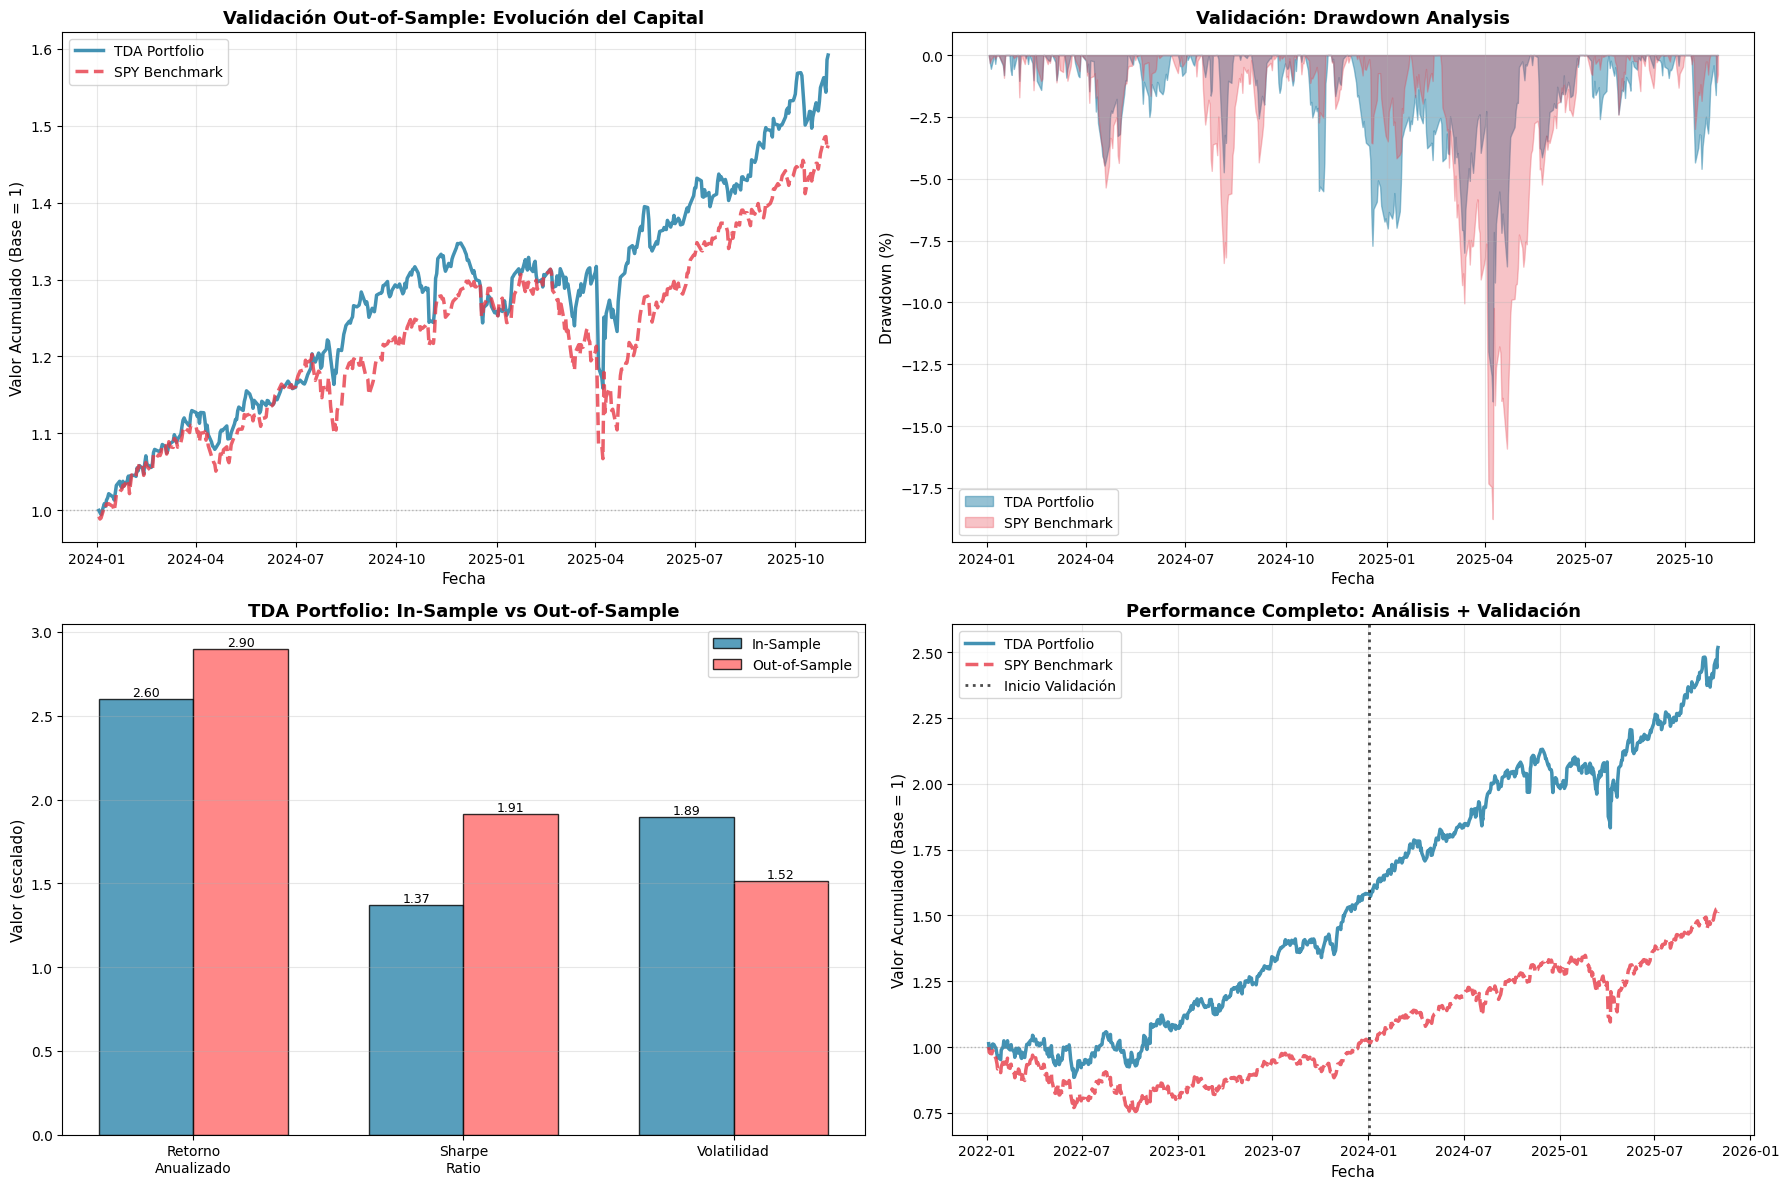

✅ Visualizaciones de validación generadas


In [59]:
# =======================================================
# 📊 PASO 12: VISUALIZACIÓN DE VALIDACIÓN
# =======================================================

print("\n" + "="*80)
print("📊 VISUALIZACIÓN OUT-OF-SAMPLE")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Evolución en validación
ax1 = axes[0, 0]
ax1.plot(portfolio_val_cumulative.index, portfolio_val_cumulative.values, 
         linewidth=2.5, label='TDA Portfolio', color='#2E86AB', alpha=0.9)
ax1.plot(spy_val_cumulative.index, spy_val_cumulative.values, 
         linewidth=2.5, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.8)
ax1.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_title('Validación Out-of-Sample: Evolución del Capital', fontsize=13, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Valor Acumulado (Base = 1)', fontsize=11)
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# 2. Drawdown en validación
ax2 = axes[0, 1]
tda_val_running_max = portfolio_val_cumulative.cummax()
tda_val_drawdown = (portfolio_val_cumulative - tda_val_running_max) / tda_val_running_max * 100

spy_val_running_max = spy_val_cumulative.cummax()
spy_val_drawdown = (spy_val_cumulative - spy_val_running_max) / spy_val_running_max * 100

ax2.fill_between(tda_val_drawdown.index, tda_val_drawdown.values, 0, 
                  alpha=0.5, color='#2E86AB', label='TDA Portfolio')
ax2.fill_between(spy_val_drawdown.index, spy_val_drawdown.values, 0, 
                  alpha=0.3, color='#E63946', label='SPY Benchmark')
ax2.set_title('Validación: Drawdown Analysis', fontsize=13, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.legend(fontsize=10, loc='best')
ax2.grid(True, alpha=0.3)

# 3. Comparación In-Sample vs Out-of-Sample (TDA)
ax3 = axes[1, 0]
metrics_names = ['Retorno\nAnualizado', 'Sharpe\nRatio', 'Volatilidad']
is_values = [tda_metrics['annualized_return']/10, tda_metrics['sharpe_ratio'], tda_metrics['volatility']/10]
oos_values = [tda_val_metrics['annualized_return']/10, tda_val_metrics['sharpe_ratio'], tda_val_metrics['volatility']/10]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax3.bar(x - width/2, is_values, width, label='In-Sample', color='#2E86AB', alpha=0.8, edgecolor='black')
bars2 = ax3.bar(x + width/2, oos_values, width, label='Out-of-Sample', color='#FF6B6B', alpha=0.8, edgecolor='black')

ax3.set_ylabel('Valor (escalado)', fontsize=11)
ax3.set_title('TDA Portfolio: In-Sample vs Out-of-Sample', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics_names, fontsize=10)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Añadir valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

# 4. Retornos acumulados completos (análisis + validación)
ax4 = axes[1, 1]

# Concatenar períodos
portfolio_full = pd.concat([portfolio_cumulative, portfolio_val_cumulative * portfolio_cumulative.iloc[-1]])
spy_full = pd.concat([spy_cumulative, spy_val_cumulative * spy_cumulative.iloc[-1]])

ax4.plot(portfolio_full.index, portfolio_full.values, 
         linewidth=2.5, label='TDA Portfolio', color='#2E86AB', alpha=0.9)
ax4.plot(spy_full.index, spy_full.values, 
         linewidth=2.5, label='SPY Benchmark', color='#E63946', linestyle='--', alpha=0.8)

# Marcar separación entre períodos
sep_date = validation_data.index[0]
ax4.axvline(x=sep_date, color='black', linestyle=':', linewidth=2, alpha=0.7, label='Inicio Validación')
ax4.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)

ax4.set_title('Performance Completo: Análisis + Validación', fontsize=13, fontweight='bold')
ax4.set_xlabel('Fecha', fontsize=11)
ax4.set_ylabel('Valor Acumulado (Base = 1)', fontsize=11)
ax4.legend(fontsize=10, loc='best')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizaciones de validación generadas")
print("="*80)

# 📊 Resumen de la Estrategia TDA

 ✅ Implementación Completada

**Objetivo:** Replicar la estrategia de construcción de portafolio usando Topological Data Analysis (TDA) del artículo "Portfolio Construction Using Topological Data Analysis"

🔧 Pasos Implementados

1. **Selección de Universo** - Top 200 componentes del S&P 500 por market cap
2. **Cálculo de Log-Returns** - Transformación logarítmica de los retornos
3. **Reducción de Dimensionalidad** - PCA (80% varianza) + UMAP (1D)
4. **Clustering Topológico** - DBSCAN con métrica de correlación
5. **Construcción de Grafo** - KeplerMapper para estructura topológica
6. **Asignación de Pesos** - Equal weighting por cluster
7. **Backtesting** - Período in-sample (análisis)
8. **Validación** - Período out-of-sample
9. **Métricas de Performance** - Sharpe, Drawdown, Beta, Alpha
10. **Visualizaciones** - Gráficos comparativos vs SPY

 📈 Características Clave

- **Lookback Window:** Período completo de análisis (2015-2024)
- **Universo:** Top 200 tickers por capitalización de mercado
- **Benchmark:** SPY (S&P 500 ETF)
- **Estrategia de Pesos:** Igual peso por cluster, distribuido equitativamente entre tickers
- **Validación:** Out-of-sample desde 2024-01-01

 🎯 Próximos Pasos Opcionales

- Implementar **rebalanceo periódico** (cada 125 días según el artículo)
- Agregar análisis de **sensibilidad** a parámetros de DBSCAN
- Comparar con benchmark de **Top 200 equal-weighted**
- Implementar **rolling window backtest** para múltiples períodos

# Analisis portafolio generado

In [60]:
# =======================================================
# 📊 ANÁLISIS DETALLADO DEL PORTAFOLIO GENERADO
# =======================================================

print("="*80)
print("📊 ANÁLISIS COMPLETO DEL PORTAFOLIO TDA")
print("="*80)

# Crear análisis detallado por ticker
portfolio_analysis = []

for ticker in portfolio_weights.keys():
    # Información básica
    info = ticker_info_db.get(ticker, {})
    metrics = financial_metrics_dict.get(ticker, {})
    
    # Buscar cluster
    ticker_cluster = None
    for cid, members in node_clusters.items():
        if ticker in members:
            ticker_cluster = cid
            break
    
    # Performance en período de análisis
    ticker_prices = tickers_data[ticker]
    ticker_returns = ticker_prices.pct_change().dropna()
    
    # Calcular métricas individuales
    total_return = (ticker_prices.iloc[-1] / ticker_prices.iloc[0] - 1) * 100
    volatility = ticker_returns.std() * np.sqrt(252) * 100
    sharpe = metrics.get('sharpe_ratio', 0)
    
    portfolio_analysis.append({
        'Ticker': ticker,
        'Peso (%)': portfolio_weights[ticker] * 100,
        'Cluster': str(ticker_cluster),
        'Sector': info.get('sector', 'Unknown'),
        'Market Cap ($B)': info.get('market_cap', 0) / 1e9,
        'Retorno Total (%)': total_return,
        'Volatilidad (%)': volatility,
        'Sharpe Ratio': sharpe,
        'Max Drawdown (%)': metrics.get('max_drawdown', 0) * 100,
        'Beta': info.get('beta', np.nan)
    })

# Crear DataFrame
portfolio_df = pd.DataFrame(portfolio_analysis)
portfolio_df = portfolio_df.sort_values('Peso (%)', ascending=False)

print(f"\n📋 COMPOSICIÓN DEL PORTAFOLIO ({len(portfolio_df)} tickers):")
print("="*80)
display(portfolio_df.round(4))

print(f"\n📊 ESTADÍSTICAS AGREGADAS DEL PORTAFOLIO:")
print("="*80)
print(f"{'Peso promedio por ticker:':<35} {portfolio_df['Peso (%)'].mean():.4f}%")
print(f"{'Peso máximo:':<35} {portfolio_df['Peso (%)'].max():.4f}%")
print(f"{'Peso mínimo:':<35} {portfolio_df['Peso (%)'].min():.4f}%")
print(f"{'Desv. estándar de pesos:':<35} {portfolio_df['Peso (%)'].std():.4f}%")
print(f"\n{'Retorno promedio (ponderado):':<35} {(portfolio_df['Retorno Total (%)'] * portfolio_df['Peso (%)'] / 100).sum():.2f}%")
print(f"{'Volatilidad promedio (ponderado):':<35} {(portfolio_df['Volatilidad (%)'] * portfolio_df['Peso (%)'] / 100).sum():.2f}%")
print(f"{'Sharpe promedio (ponderado):':<35} {(portfolio_df['Sharpe Ratio'] * portfolio_df['Peso (%)'] / 100).sum():.4f}")
print(f"\n{'Market Cap promedio:':<35} ${portfolio_df['Market Cap ($B)'].mean():.2f}B")
print(f"{'Market Cap total del portafolio:':<35} ${portfolio_df['Market Cap ($B)'].sum():.2f}B")

print(f"\n📊 DISTRIBUCIÓN POR SECTORES:")
print("="*80)
sector_stats = portfolio_df.groupby('Sector').agg({
    'Peso (%)': 'sum',
    'Ticker': 'count',
    'Retorno Total (%)': 'mean',
    'Volatilidad (%)': 'mean'
}).rename(columns={'Ticker': 'Num Tickers'})
sector_stats = sector_stats.sort_values('Peso (%)', ascending=False)

for sector, row in sector_stats.iterrows():
    print(f"{sector:30s}: {row['Peso (%)']:6.2f}% ({int(row['Num Tickers']):2d} tickers) | "
          f"Ret Avg: {row['Retorno Total (%)']:6.2f}% | Vol Avg: {row['Volatilidad (%)']:5.2f}%")

print(f"\n📊 DISTRIBUCIÓN POR CLUSTERS:")
print("="*80)
cluster_stats = portfolio_df.groupby('Cluster').agg({
    'Peso (%)': 'sum',
    'Ticker': 'count'
}).rename(columns={'Ticker': 'Num Tickers'})
cluster_stats = cluster_stats.sort_values('Peso (%)', ascending=False)

for cluster, row in cluster_stats.iterrows():
    print(f"Cluster {cluster:>10s}: {row['Peso (%)']:6.2f}% ({int(row['Num Tickers']):2d} tickers)")

print("="*80)

📊 ANÁLISIS COMPLETO DEL PORTAFOLIO TDA

📋 COMPOSICIÓN DEL PORTAFOLIO (12 tickers):


,Ticker,Peso (%),Cluster,Sector,Market Cap ($B),Retorno Total (%),Volatilidad (%),Sharpe Ratio,Max Drawdown (%),Beta
0,WELL,8.3333,cube0_cluster0,Real Estate,47.9150,12.0366,26.3654,0.3488,-40.7830,NaN
1,PHM,8.3333,cube1_cluster0,Consumer Cyclical,21.9726,88.3080,37.7214,1.0339,-36.0802,NaN
2,V,8.3333,cube2_cluster0,Financial Services,527.2649,19.4068,24.4788,0.4866,-24.1379,NaN
3,CTAS,8.3333,cube3_cluster0,Industrials,15.0245,45.0754,23.5193,0.9150,-19.8022,NaN
4,FICO,8.3333,cube4_cluster0,Technology,28.7669,162.6791,40.3081,1.3989,-34.7687,NaN
5,CAH,8.3333,cube4_cluster1,Healthcare,24.1463,104.6303,24.3116,1.6064,-20.9521,NaN
6,AAPL,8.3333,cube5_cluster0,Technology,2966.3664,6.9886,29.0755,0.2619,-30.9128,NaN
7,GOOG,8.3333,cube5_cluster0,Communication Services,1743.3950,-2.8568,35.0391,0.1334,-43.6017,NaN
8,MPC,8.3333,cube6_cluster0,Energy,54.0078,137.2760,33.4097,1.4715,-30.2156,NaN
9,ACGL,8.3333,cube7_cluster0,Financial Services,26.3546,66.7116,26.7496,1.0967,-18.4222,NaN



📊 ESTADÍSTICAS AGREGADAS DEL PORTAFOLIO:
Peso promedio por ticker:           8.3333%
Peso máximo:                        8.3333%
Peso mínimo:                        8.3333%
Desv. estándar de pesos:            0.0000%

Retorno promedio (ponderado):       58.17%
Volatilidad promedio (ponderado):   29.25%
Sharpe promedio (ponderado):        0.8337

Market Cap promedio:                $494.62B
Market Cap total del portafolio:    $5935.46B

📊 DISTRIBUCIÓN POR SECTORES:
Financial Services            :  25.00% ( 3 tickers) | Ret Avg:  32.62% | Vol Avg: 25.65%
Industrials                   :  16.67% ( 2 tickers) | Ret Avg:  45.55% | Vol Avg: 23.93%
Technology                    :  16.67% ( 2 tickers) | Ret Avg:  84.83% | Vol Avg: 34.69%
Communication Services        :   8.33% ( 1 tickers) | Ret Avg:  -2.86% | Vol Avg: 35.04%
Consumer Cyclical             :   8.33% ( 1 tickers) | Ret Avg:  88.31% | Vol Avg: 37.72%
Energy                        :   8.33% ( 1 tickers) | Ret Avg: 137.28% | Vol Av

# Faltantes

In [61]:
# =======================================================
# 🔍 DIAGNÓSTICO: VERIFICAR CLUSTERS Y TICKERS FALTANTES
# =======================================================

print("\n" + "="*80)
print("🔍 DIAGNÓSTICO: Clusters vs Tickers en Portafolio")
print("="*80)

# 1. Contar clusters
num_clusters = len(node_clusters)
print(f"\n📊 Número de clusters en node_clusters: {num_clusters}")

# 2. Contar tickers en portfolio_weights
num_tickers_portfolio = len(portfolio_weights)
print(f"📊 Número de tickers en portfolio_weights: {num_tickers_portfolio}")

# 3. Verificar suma de pesos
suma_pesos = sum(portfolio_weights.values())
print(f"📊 Suma de pesos en portfolio_weights: {suma_pesos:.6f}")
print(f"   {'✅ Correcto' if abs(suma_pesos - 1.0) < 0.001 else '❌ PROBLEMA: No suma 1.0!'}")

# 4. Mostrar peso individual esperado vs real
peso_esperado = 1.0 / num_clusters
peso_real_promedio = sum(portfolio_weights.values()) / len(portfolio_weights)
print(f"\n📊 Peso esperado por ticker (1/{num_clusters}): {peso_esperado:.6f} ({peso_esperado*100:.2f}%)")
print(f"📊 Peso real promedio: {peso_real_promedio:.6f} ({peso_real_promedio*100:.2f}%)")

# 5. Identificar clusters sin ticker
clusters_con_ticker = set()
for ticker in portfolio_weights.keys():
    for cid, members in node_clusters.items():
        if ticker in members:
            clusters_con_ticker.add(cid)
            break

clusters_sin_ticker = set(node_clusters.keys()) - clusters_con_ticker
print(f"\n📊 Clusters con ticker asignado: {len(clusters_con_ticker)}/{num_clusters}")
print(f"📊 Clusters SIN ticker asignado: {len(clusters_sin_ticker)}")

if clusters_sin_ticker:
    print(f"\n⚠️  CLUSTERS FALTANTES:")
    for cid in sorted(clusters_sin_ticker):
        print(f"   Cluster {cid}: {len(node_clusters[cid])} miembros - {list(node_clusters[cid])[:3]}...")

# 6. Verificar si los tickers del portafolio están en tickers_data
tickers_faltantes_en_data = [t for t in portfolio_weights.keys() if t not in tickers_data.columns]
if tickers_faltantes_en_data:
    print(f"\n⚠️  TICKERS EN PORTFOLIO PERO NO EN tickers_data:")
    for t in tickers_faltantes_en_data:
        print(f"   {t}")

print("\n" + "="*80)
print("💡 RECOMENDACIÓN:")
if clusters_sin_ticker:
    print("   Hay clusters sin ticker asignado. Esto causa que el portafolio no sume 100%.")
    print("   Solución: Ajustar pesos para que sumen exactamente 1.0")
    print(f"   Peso que falta: {(1.0 - suma_pesos)*100:.2f}%")
elif suma_pesos < 0.999:
    print(f"   Los pesos solo suman {suma_pesos:.4f} en lugar de 1.0")
    print(f"   Falta: {(1.0 - suma_pesos)*100:.2f}%")
else:
    print("   ✅ Todo correcto: Todos los clusters tienen ticker y los pesos suman 1.0")
print("="*80)



🔍 DIAGNÓSTICO: Clusters vs Tickers en Portafolio

📊 Número de clusters en node_clusters: 12
📊 Número de tickers en portfolio_weights: 12
📊 Suma de pesos en portfolio_weights: 1.000000
   ✅ Correcto

📊 Peso esperado por ticker (1/12): 0.083333 (8.33%)
📊 Peso real promedio: 0.083333 (8.33%)

📊 Clusters con ticker asignado: 11/12
📊 Clusters SIN ticker asignado: 1

⚠️  CLUSTERS FALTANTES:
   Cluster cube9_cluster0: 17 miembros - ['BAC', 'BK', 'C']...

💡 RECOMENDACIÓN:
   Hay clusters sin ticker asignado. Esto causa que el portafolio no sume 100%.
   Solución: Ajustar pesos para que sumen exactamente 1.0
   Peso que falta: 0.00%


In [62]:
# =======================================================
# 🔧 CORRECCIÓN: NORMALIZAR PESOS PARA QUE SUMEN 1.0
# =======================================================

print("\n" + "="*80)
print("🔧 CORRECCIÓN: Normalizando pesos del portafolio")
print("="*80)

# Verificar suma actual
suma_original = sum(portfolio_weights.values())
print(f"\n📊 Suma de pesos ANTES de corrección: {suma_original:.6f}")

if abs(suma_original - 1.0) > 0.001:
    print(f"   ⚠️  Los pesos no suman 1.0, normalizando...")
    
    # Normalizar pesos para que sumen exactamente 1.0
    portfolio_weights_corrected = {
        ticker: peso / suma_original 
        for ticker, peso in portfolio_weights.items()
    }
    
    # Verificar
    suma_corregida = sum(portfolio_weights_corrected.values())
    print(f"📊 Suma de pesos DESPUÉS de corrección: {suma_corregida:.10f}")
    print(f"   ✅ Correcto!")
    
    # Mostrar diferencia
    print(f"\n📊 Comparación de pesos:")
    print(f"{'Ticker':<10} {'Peso Original (%)':<20} {'Peso Corregido (%)':<20} {'Diferencia':<15}")
    print("-"*70)
    for ticker in sorted(portfolio_weights.keys()):
        peso_orig = portfolio_weights[ticker] * 100
        peso_corr = portfolio_weights_corrected[ticker] * 100
        diff = peso_corr - peso_orig
        print(f"{ticker:<10} {peso_orig:>18.4f}% {peso_corr:>19.4f}% {diff:>+14.4f}%")
    
    # Reemplazar portfolio_weights con la versión corregida
    portfolio_weights = portfolio_weights_corrected
    print(f"\n✅ portfolio_weights actualizado con pesos normalizados")
    
else:
    print(f"   ✅ Los pesos ya suman 1.0, no se requiere corrección")

print("="*80)



🔧 CORRECCIÓN: Normalizando pesos del portafolio

📊 Suma de pesos ANTES de corrección: 1.000000
   ✅ Los pesos ya suman 1.0, no se requiere corrección



📊 GRÁFICA 1: EVOLUCIÓN DE PRECIOS ORIGINALES


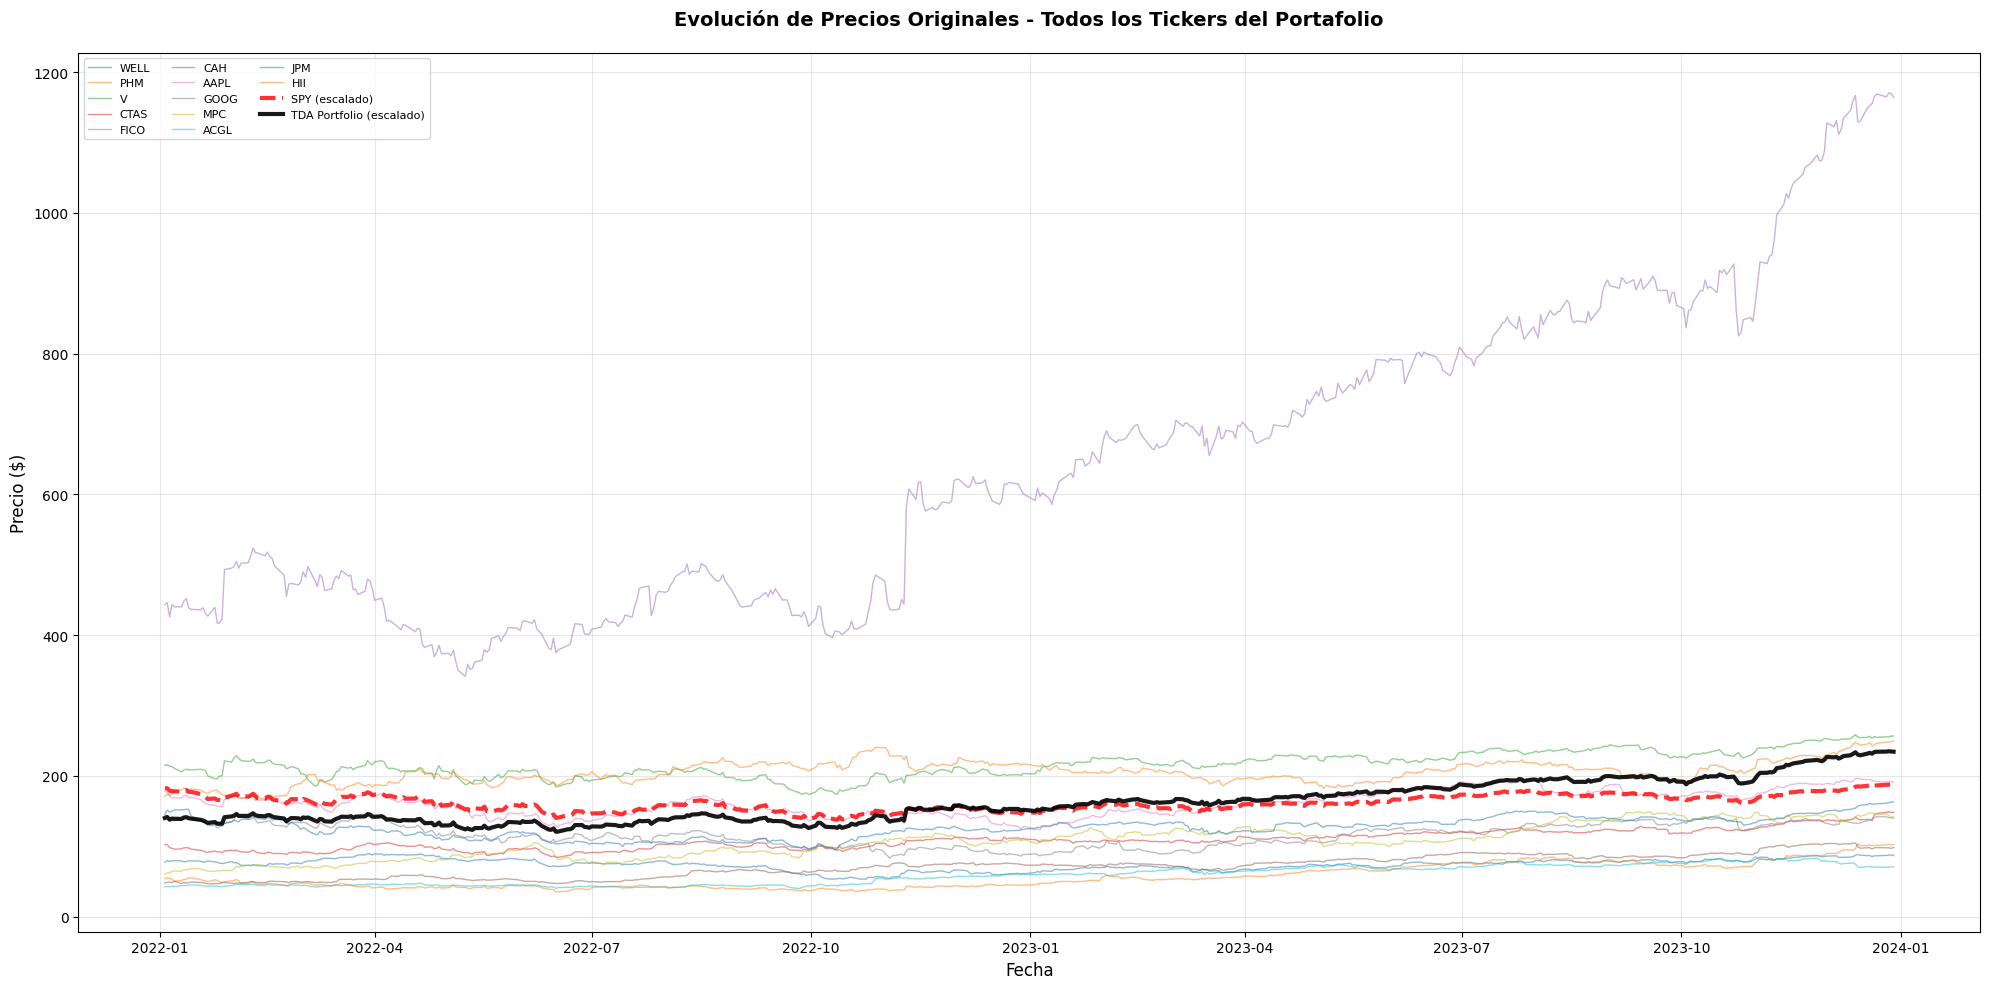

✅ Gráfica 1 generada: Precios originales de 12 tickers


In [63]:
# =======================================================
# 📊 GRÁFICA 1: VALORES ORIGINALES (PRECIOS ABSOLUTOS)
# =======================================================

print("\n" + "="*80)
print("📊 GRÁFICA 1: EVOLUCIÓN DE PRECIOS ORIGINALES")
print("="*80)

fig = plt.figure(figsize=(20, 10))

# Obtener datos de precios para todos los tickers del portafolio
portfolio_tickers_list = list(portfolio_weights.keys())
prices_data = tickers_data[portfolio_tickers_list].copy()

# Crear subplot
ax = plt.subplot(1, 1, 1)

# Graficar cada ticker individual
for ticker in portfolio_tickers_list:
    ax.plot(prices_data.index, prices_data[ticker], 
            alpha=0.5, linewidth=1, label=ticker if len(portfolio_tickers_list) <= 20 else '')

# Graficar SPY (normalizar para que esté en escala comparable)
spy_prices = SPY_analysis['SPY']
spy_scaled = spy_prices * (prices_data.mean().mean() / spy_prices.mean())  # Escalar SPY
ax.plot(spy_prices.index, spy_scaled, 
        linewidth=3, color='red', linestyle='--', label='SPY (escalado)', alpha=0.8)

# Calcular y graficar portafolio (valor ponderado)
portfolio_value = (prices_data * list(portfolio_weights.values())).sum(axis=1)
portfolio_scaled = portfolio_value * (prices_data.mean().mean() / portfolio_value.mean())
ax.plot(prices_data.index, portfolio_scaled, 
        linewidth=3, color='black', label='TDA Portfolio (escalado)', alpha=0.9)

ax.set_title('Evolución de Precios Originales - Todos los Tickers del Portafolio', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Precio ($)', fontsize=12)
ax.grid(True, alpha=0.3)

# Leyenda solo si hay pocos tickers
if len(portfolio_tickers_list) <= 20:
    ax.legend(loc='upper left', fontsize=8, ncol=3)
else:
    # Leyenda simplificada
    ax.plot([], [], alpha=0.5, linewidth=1, color='gray', label=f'{len(portfolio_tickers_list)} tickers individuales')
    ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print(f"✅ Gráfica 1 generada: Precios originales de {len(portfolio_tickers_list)} tickers")
print("="*80)


📊 GRÁFICA 2A: EVOLUCIÓN NORMALIZADA - PERÍODO DE ANÁLISIS (Base = 1)


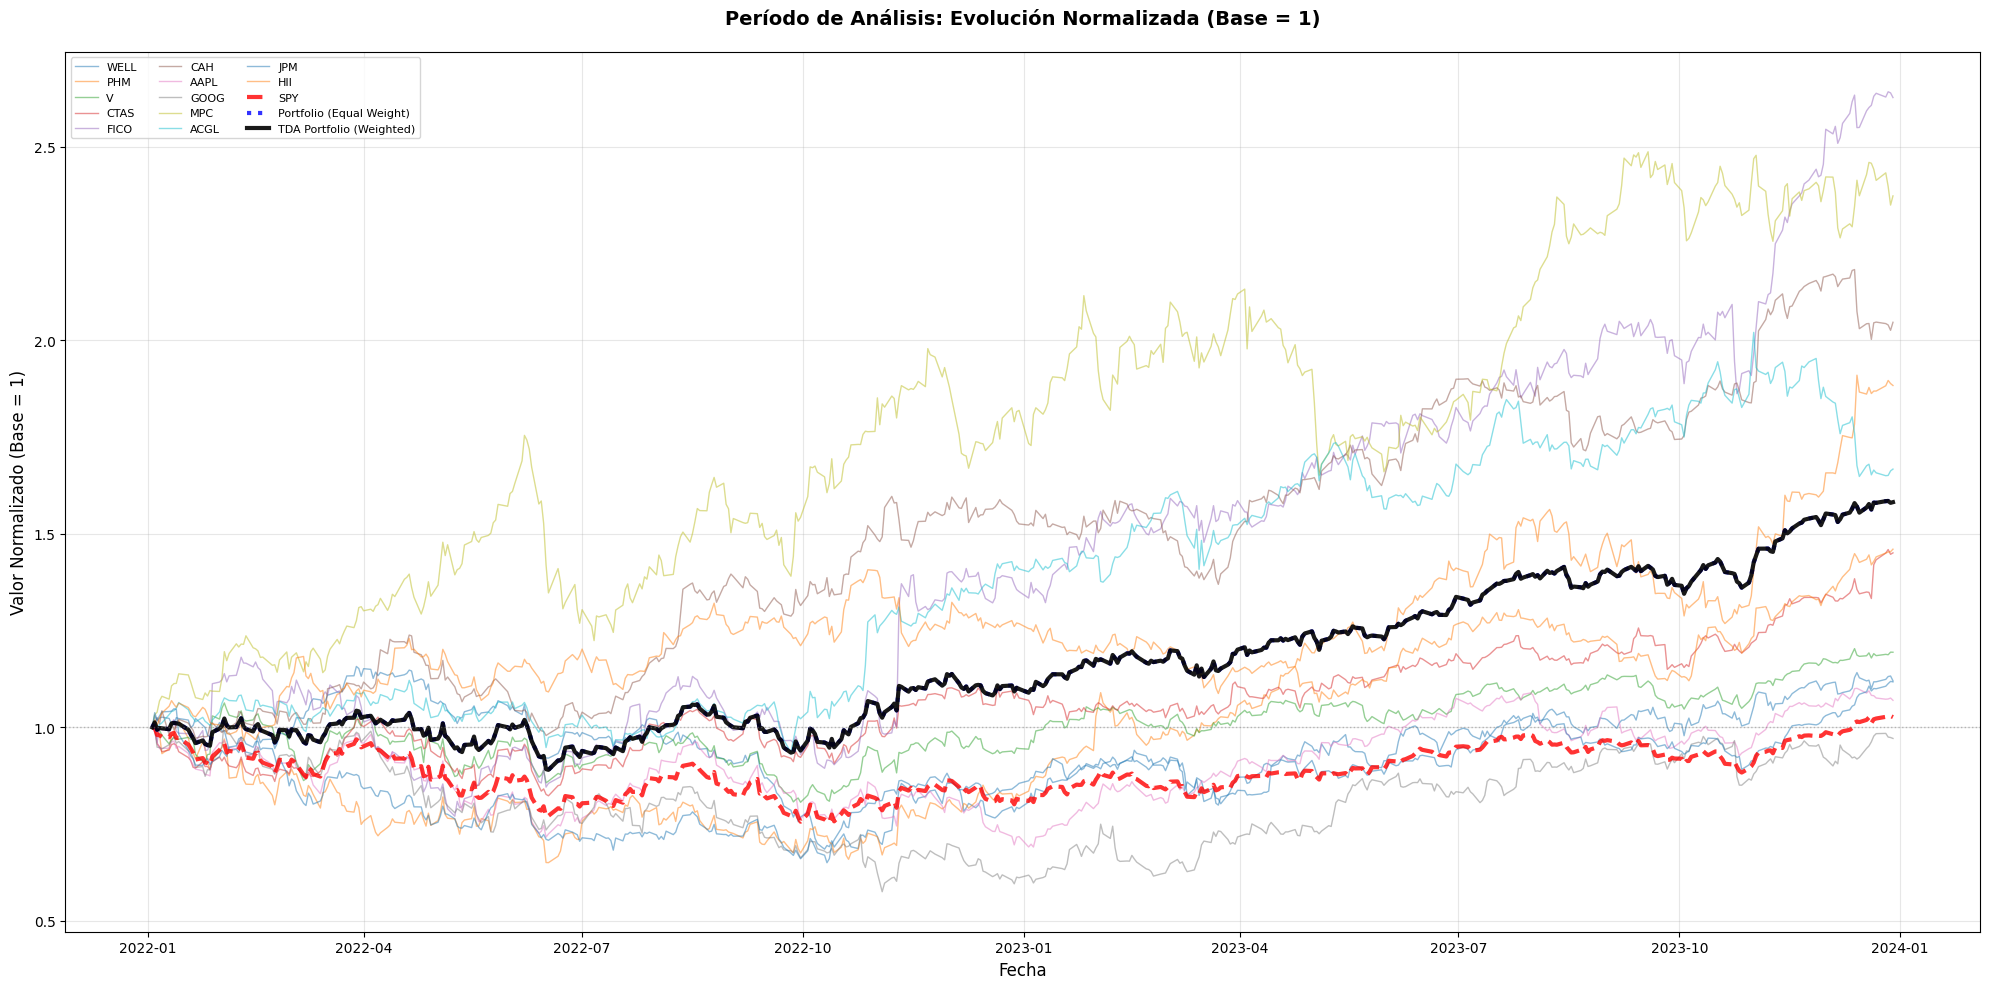

✅ Gráfica 2A generada: Período de análisis - 12 tickers (base = 1)


In [64]:
# =======================================================
# 📊 GRÁFICA 2A: NORMALIZADO - PERÍODO DE ANÁLISIS (ENTRENAMIENTO)
# =======================================================

print("\n" + "="*80)
print("📊 GRÁFICA 2A: EVOLUCIÓN NORMALIZADA - PERÍODO DE ANÁLISIS (Base = 1)")
print("="*80)

fig = plt.figure(figsize=(20, 10))
ax = plt.subplot(1, 1, 1)

# Normalizar cada ticker (empezar en 1)
prices_normalized = prices_data / prices_data.iloc[0]

# Graficar cada ticker normalizado
for ticker in portfolio_tickers_list:
    ax.plot(prices_normalized.index, prices_normalized[ticker], 
            alpha=0.5, linewidth=1, label=ticker if len(portfolio_tickers_list) <= 20 else '')

# SPY normalizado
spy_normalized = spy_prices / spy_prices.iloc[0]
ax.plot(spy_normalized.index, spy_normalized, 
        linewidth=3, color='red', linestyle='--', label='SPY', alpha=0.8)

# Portafolio normalizado (equal weight para comparación)
portfolio_equal_weight = prices_normalized.mean(axis=1)
ax.plot(prices_normalized.index, portfolio_equal_weight, 
        linewidth=3, color='blue', linestyle=':', label='Portfolio (Equal Weight)', alpha=0.8)

# Portafolio TDA (con pesos reales) - CORREGIDO para empezar exactamente en 1
weights_array = np.array([portfolio_weights[ticker] for ticker in portfolio_tickers_list])
portfolio_tda_normalized = (prices_normalized[portfolio_tickers_list].values * weights_array).sum(axis=1)
ax.plot(prices_normalized.index, portfolio_tda_normalized, 
        linewidth=3, color='black', label='TDA Portfolio (Weighted)', alpha=0.9)

ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax.set_title('Período de Análisis: Evolución Normalizada (Base = 1)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Valor Normalizado (Base = 1)', fontsize=12)
ax.grid(True, alpha=0.3)

if len(portfolio_tickers_list) <= 20:
    ax.legend(loc='upper left', fontsize=8, ncol=3)
else:
    ax.plot([], [], alpha=0.5, linewidth=1, color='gray', label=f'{len(portfolio_tickers_list)} tickers individuales')
    ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print(f"✅ Gráfica 2A generada: Período de análisis - {len(portfolio_tickers_list)} tickers (base = 1)")
print("="*80)


📊 GRÁFICA 3: CONTRIBUCIÓN PONDERADA AL PORTAFOLIO (Base = 1)


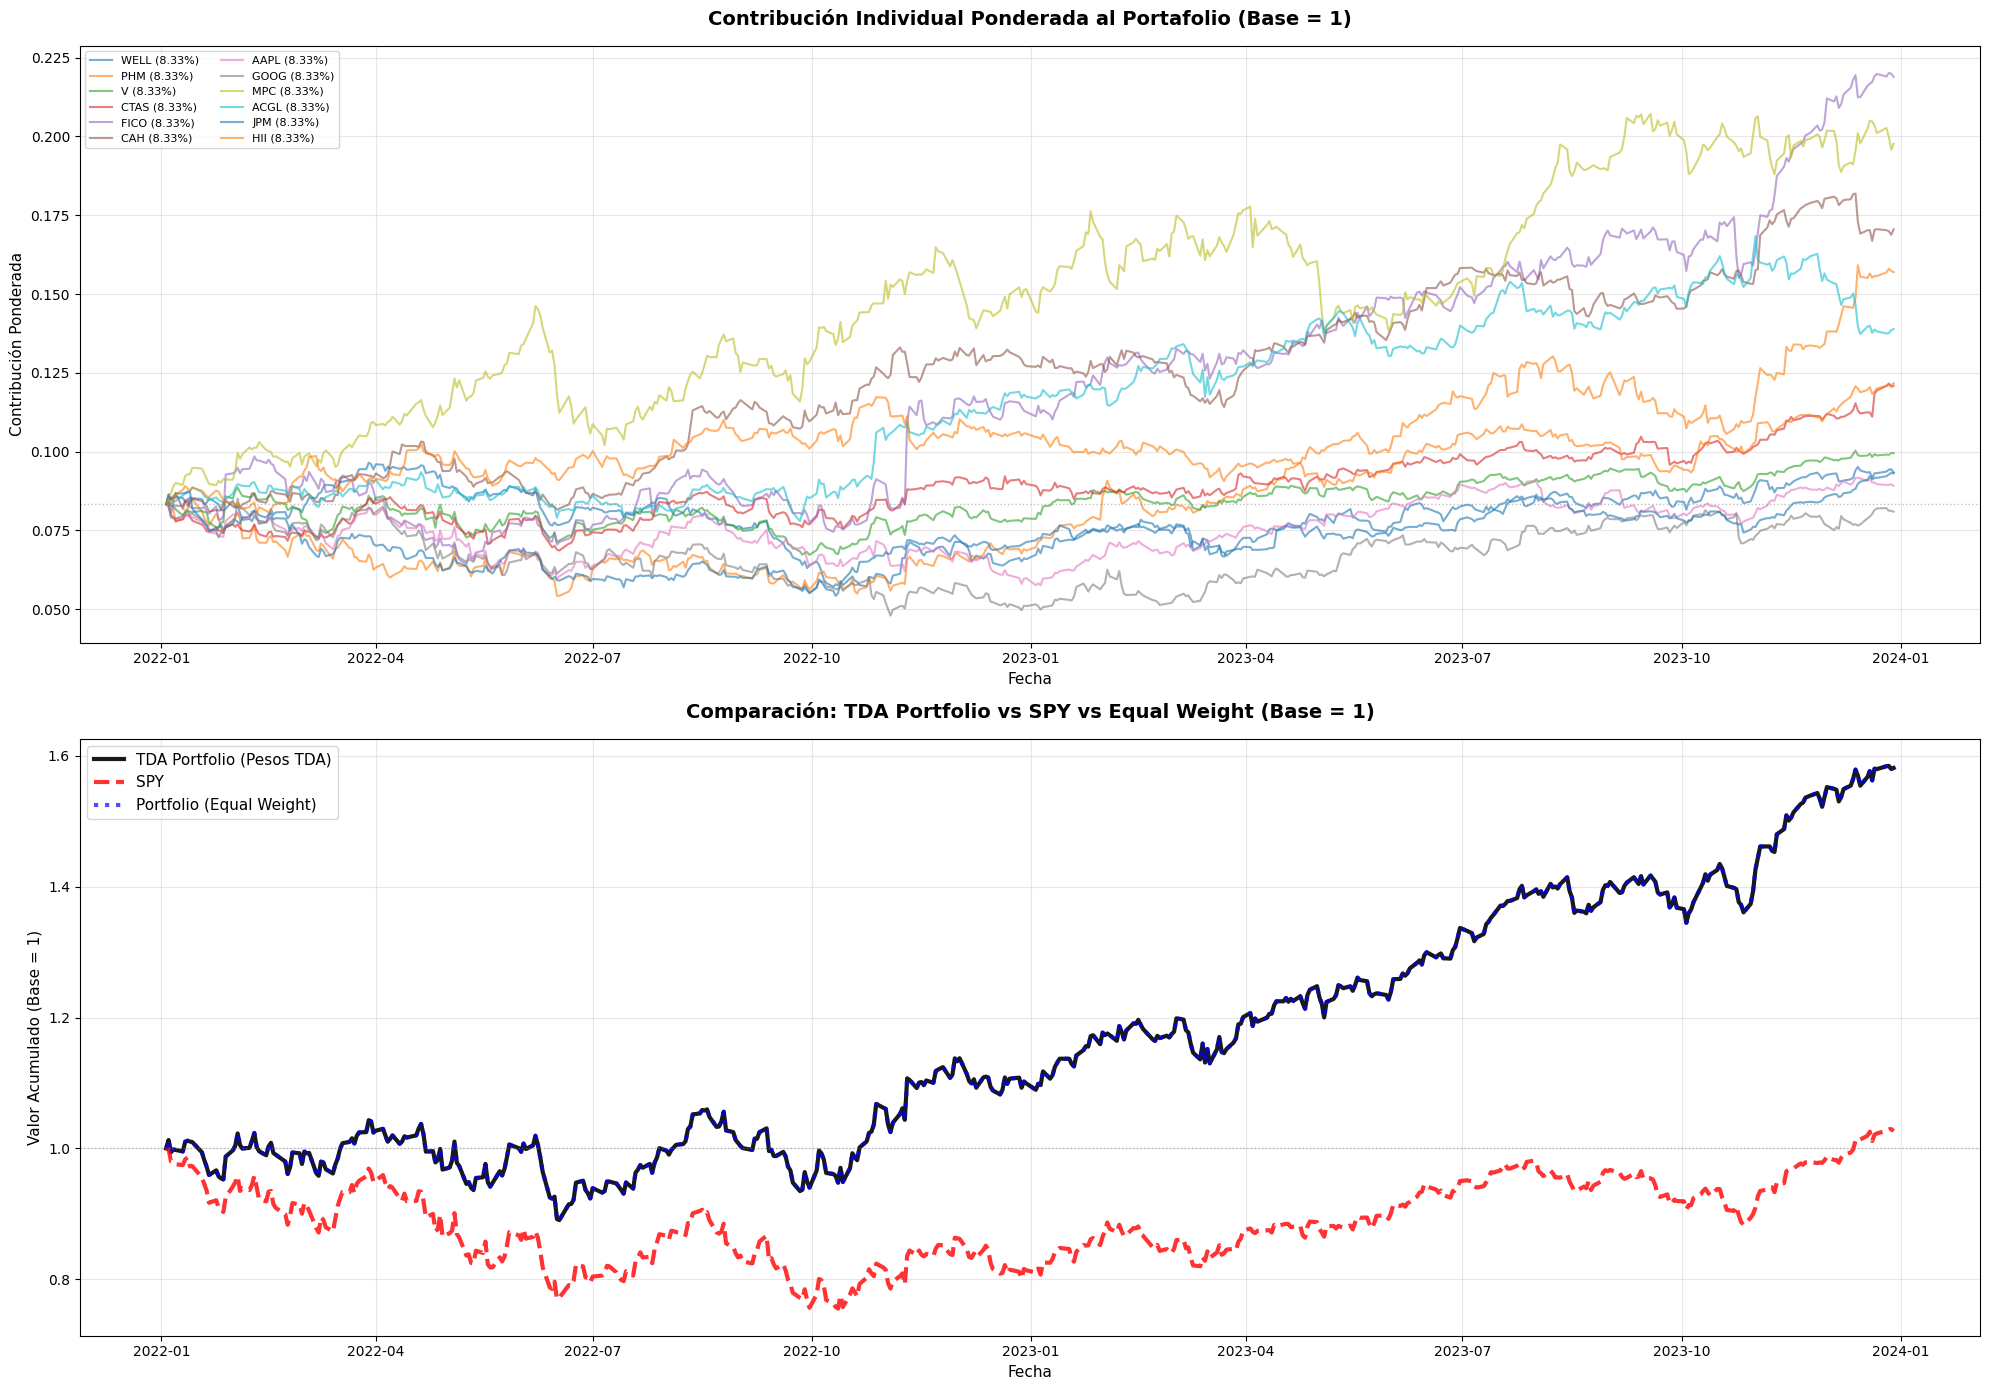

✅ Gráfica 3 generada: Contribución ponderada de 12 tickers


In [71]:
# =======================================================
# 📊 GRÁFICA 3: NORMALIZADO CON PESOS (BASE = 1, PONDERADO)
# =======================================================

print("\n" + "="*80)
print("📊 GRÁFICA 3: CONTRIBUCIÓN PONDERADA AL PORTAFOLIO (Base = 1)")
print("="*80)

fig, axes = plt.subplots(2, 1, figsize=(20, 14))

# -----------------
# Panel 1: Evolución individual ponderada
# -----------------
ax1 = axes[0]

# Normalizar y ponderar cada ticker por su peso
for ticker in portfolio_tickers_list:
    ticker_weight = portfolio_weights[ticker]
    ticker_normalized_weighted = (prices_data[ticker] / prices_data[ticker].iloc[0]) * ticker_weight
    
    ax1.plot(prices_data.index, ticker_normalized_weighted, 
             alpha=0.6, linewidth=1.5, 
             label=f"{ticker} ({ticker_weight*100:.2f}%)" if len(portfolio_tickers_list) <= 15 else '')

# Portafolio TDA completo (suma de contribuciones ponderadas)
portfolio_tda_weighted = sum(
    (prices_data[ticker] / prices_data[ticker].iloc[0]) * portfolio_weights[ticker] 
    for ticker in portfolio_tickers_list
)

#ax1.plot(prices_data.index, portfolio_tda_weighted, 
#         linewidth=4, color='black', label='TDA Portfolio Total', alpha=0.9, zorder=100)

# SPY normalizado (para referencia)
#spy_normalized_ref = spy_prices / spy_prices.iloc[0]
#ax1.plot(spy_normalized_ref.index, spy_normalized_ref, 
#         linewidth=3, color='red', linestyle='--', label='SPY (referencia)', alpha=0.7)

ax1.axhline(y=0.0833, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_title('Contribución Individual Ponderada al Portafolio (Base = 1)', 
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Fecha', fontsize=11)
ax1.set_ylabel('Contribución Ponderada', fontsize=11)
ax1.grid(True, alpha=0.3)

if len(portfolio_tickers_list) <= 15:
    ax1.legend(loc='upper left', fontsize=8, ncol=2)
else:
    ax1.plot([], [], alpha=0.6, linewidth=1.5, color='gray', 
             label=f'{len(portfolio_tickers_list)} tickers (ponderados)')
    ax1.legend(loc='upper left', fontsize=10)

# -----------------
# Panel 2: Comparación Portfolio TDA vs SPY vs Equal Weight
# -----------------
ax2 = axes[1]

# Portfolio TDA (con pesos)
ax2.plot(prices_data.index, portfolio_tda_weighted, 
         linewidth=3, color='black', label='TDA Portfolio (Pesos TDA)', alpha=0.9)

# SPY normalizado
ax2.plot(spy_normalized_ref.index, spy_normalized_ref, 
         linewidth=3, color='red', linestyle='--', label='SPY', alpha=0.8)

# Portfolio Equal Weight (para comparación)
portfolio_equal_normalized = (prices_data / prices_data.iloc[0]).mean(axis=1)
ax2.plot(prices_data.index, portfolio_equal_normalized, 
         linewidth=3, color='blue', linestyle=':', label='Portfolio (Equal Weight)', alpha=0.7)

ax2.axhline(y=1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
ax2.set_title('Comparación: TDA Portfolio vs SPY vs Equal Weight (Base = 1)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Fecha', fontsize=11)
ax2.set_ylabel('Valor Acumulado (Base = 1)', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()

print(f"✅ Gráfica 3 generada: Contribución ponderada de {len(portfolio_tickers_list)} tickers")
print("="*80)


📊 ANÁLISIS VISUAL: TODOS LOS TICKERS (12 total)


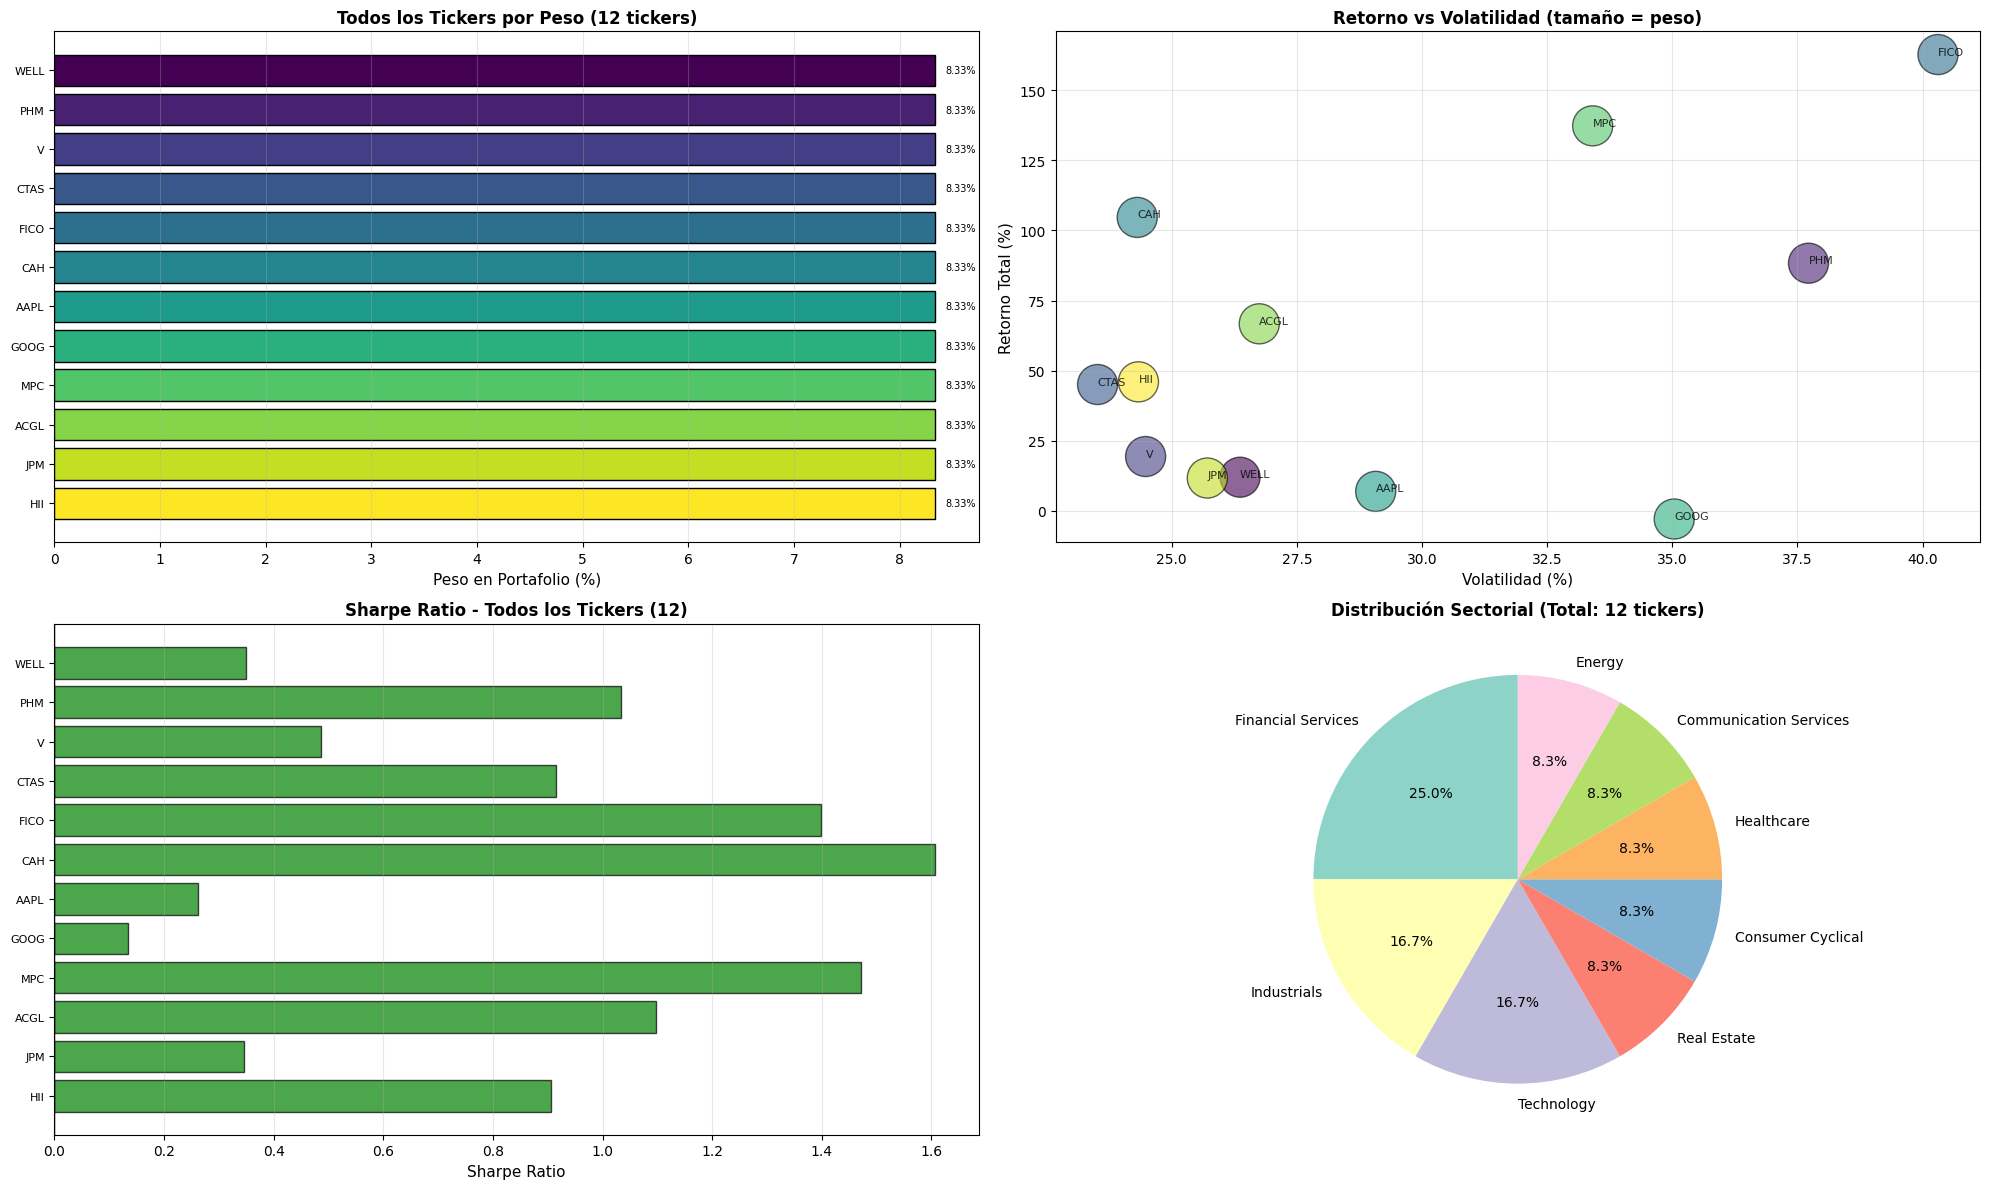

✅ Análisis visual completado para 12 tickers


In [66]:
# =======================================================
# 📊 RESUMEN VISUAL: TODOS LOS TICKERS DEL PORTAFOLIO
# =======================================================

print("\n" + "="*80)
print(f"📊 ANÁLISIS VISUAL: TODOS LOS TICKERS ({len(portfolio_df)} total)")
print("="*80)

# Usar TODOS los tickers del portafolio
all_tickers = portfolio_df.copy()

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# 1. Pesos de TODOS los tickers
ax1 = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0, 1, len(all_tickers)))
bars = ax1.barh(range(len(all_tickers)), all_tickers['Peso (%)'], color=colors, edgecolor='black')
ax1.set_yticks(range(len(all_tickers)))
ax1.set_yticklabels(all_tickers['Ticker'], fontsize=8)
ax1.set_xlabel('Peso en Portafolio (%)', fontsize=11)
ax1.set_title(f'Todos los Tickers por Peso ({len(all_tickers)} tickers)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# Añadir valores solo si no son demasiados tickers
if len(all_tickers) <= 30:
    for i, (idx, row) in enumerate(all_tickers.iterrows()):
        ax1.text(row['Peso (%)'] + 0.1, i, f"{row['Peso (%)']:.2f}%", 
                 va='center', fontsize=7)

# 2. Retorno vs Volatilidad (TODOS)
ax2 = axes[0, 1]
scatter = ax2.scatter(all_tickers['Volatilidad (%)'], all_tickers['Retorno Total (%)'], 
                      s=all_tickers['Peso (%)'] * 100, alpha=0.6, 
                      c=range(len(all_tickers)), cmap='viridis', edgecolors='black')

# Anotar solo si no son demasiados tickers
if len(all_tickers) <= 20:
    for idx, row in all_tickers.iterrows():
        ax2.annotate(row['Ticker'], 
                    (row['Volatilidad (%)'], row['Retorno Total (%)']),
                    fontsize=8, alpha=0.8)
else:
    # Anotar solo los de mayor peso
    top_annotate = all_tickers.head(10)
    for idx, row in top_annotate.iterrows():
        ax2.annotate(row['Ticker'], 
                    (row['Volatilidad (%)'], row['Retorno Total (%)']),
                    fontsize=8, alpha=0.9, fontweight='bold')

ax2.set_xlabel('Volatilidad (%)', fontsize=11)
ax2.set_ylabel('Retorno Total (%)', fontsize=11)
ax2.set_title('Retorno vs Volatilidad (tamaño = peso)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Sharpe Ratio de TODOS
ax3 = axes[1, 0]
colors_sharpe = ['green' if x > 0 else 'red' for x in all_tickers['Sharpe Ratio']]
ax3.barh(range(len(all_tickers)), all_tickers['Sharpe Ratio'], color=colors_sharpe, 
         alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(all_tickers)))
ax3.set_yticklabels(all_tickers['Ticker'], fontsize=8)
ax3.set_xlabel('Sharpe Ratio', fontsize=11)
ax3.set_title(f'Sharpe Ratio - Todos los Tickers ({len(all_tickers)})', fontsize=12, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax3.grid(True, alpha=0.3, axis='x')
ax3.invert_yaxis()

# 4. Sectores de TODOS
ax4 = axes[1, 1]
sector_counts = all_tickers['Sector'].value_counts()
ax4.pie(sector_counts, labels=sector_counts.index, autopct='%1.1f%%',
        startangle=90, colors=plt.cm.Set3(range(len(sector_counts))))
ax4.set_title(f'Distribución Sectorial (Total: {len(all_tickers)} tickers)', 
              fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"✅ Análisis visual completado para {len(all_tickers)} tickers")
print("="*80)

# 📊 GRÁFICAS DEL PERÍODO DE VALIDACIÓN (OUT-OF-SAMPLE)

## Grafica 1 validación out-of-sample


📊 GRÁFICA 1 VALIDACIÓN: Evolución Normalizada - Portafolio, SPY y Tickers

📋 Información:
   Período: 2024-01-02 a 2025-10-31
   Tickers disponibles: 12/12
   Días de trading: 461


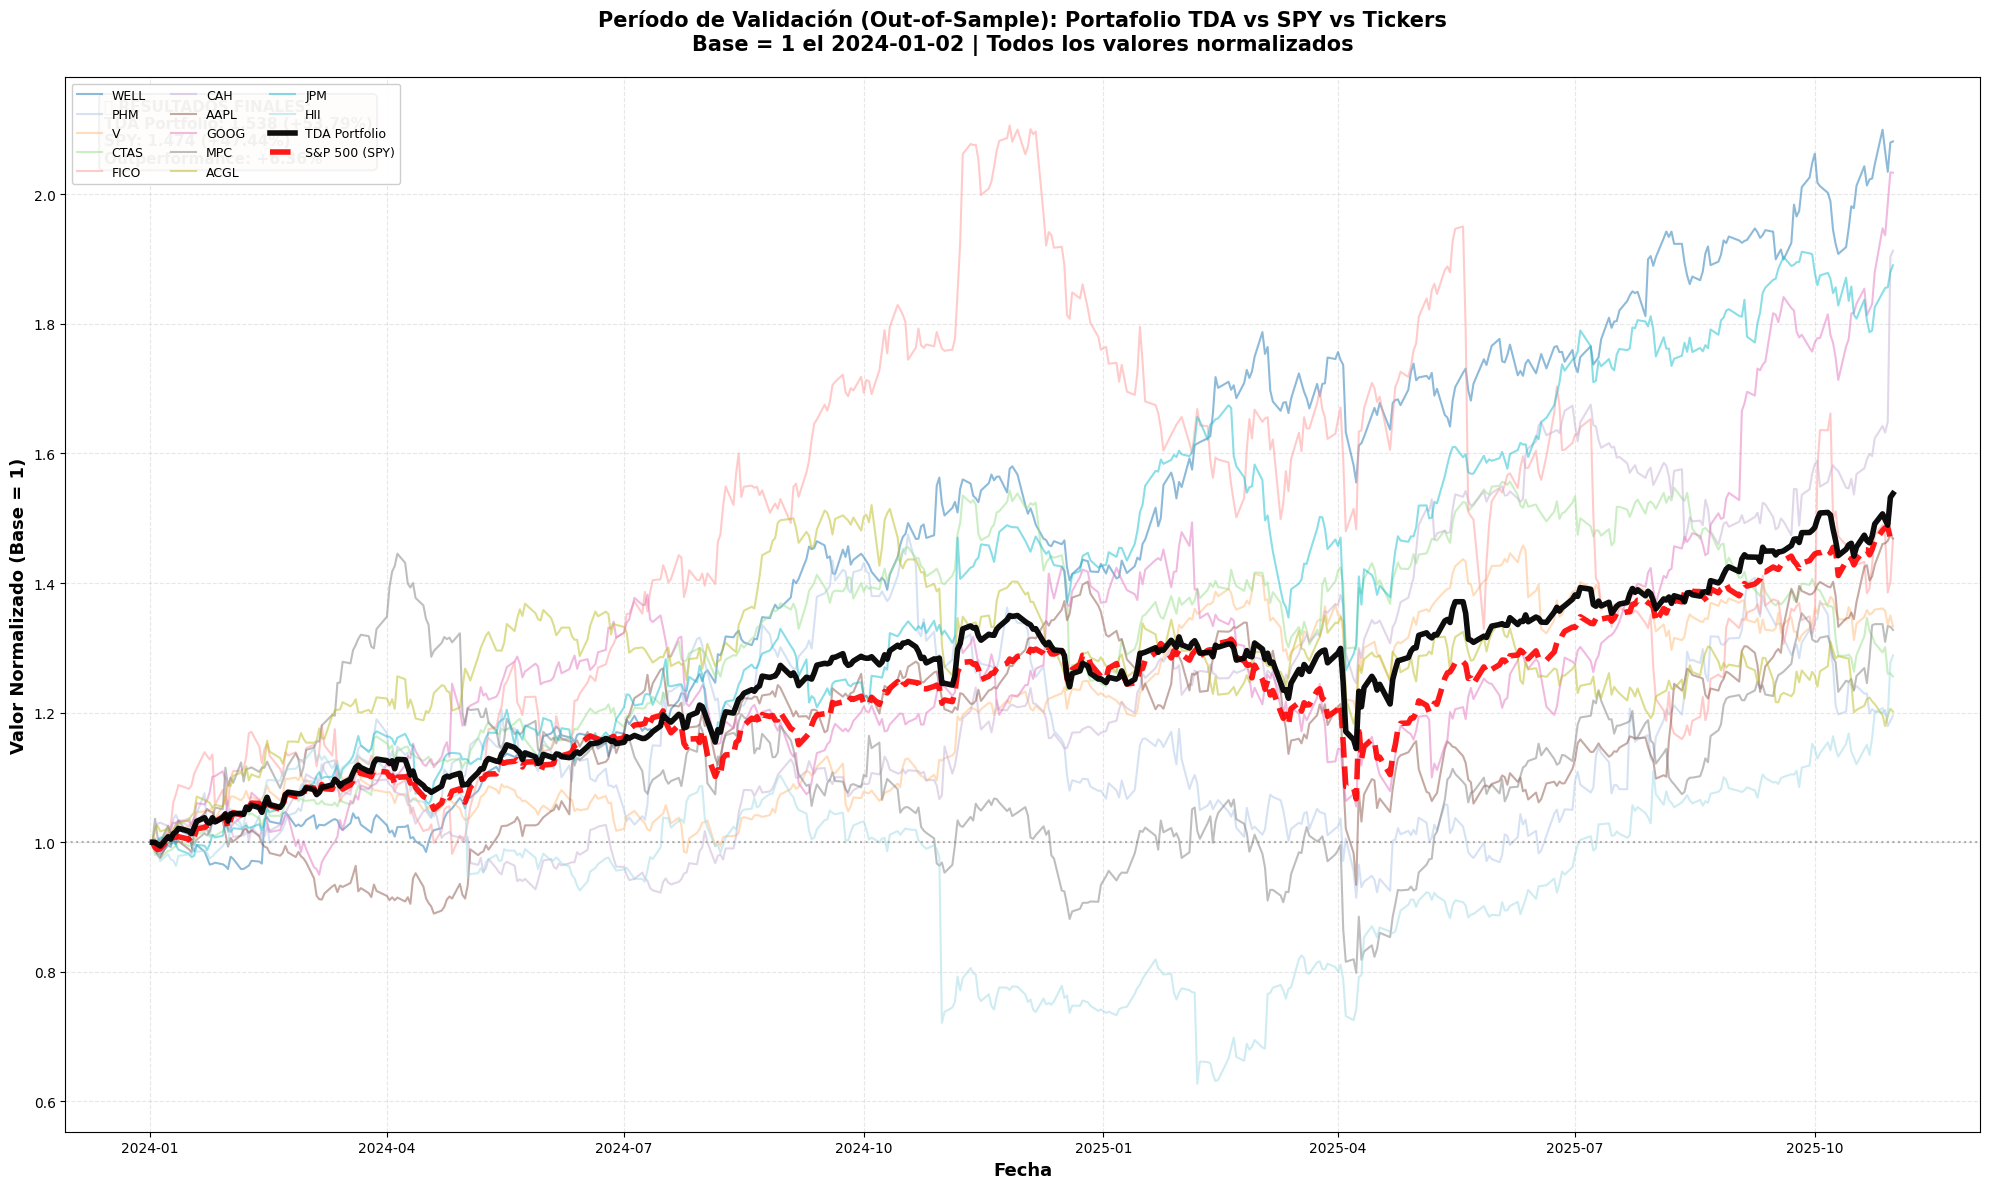

✅ Gráfica 1 Validación generada


In [67]:
# =======================================================
# 📊 GRÁFICA 1 VALIDACIÓN: PORTAFOLIO vs SPY vs TICKERS (BASE = 1)
# =======================================================

print("\n" + "="*80)
print("📊 GRÁFICA 1 VALIDACIÓN: Evolución Normalizada - Portafolio, SPY y Tickers")
print("="*80)

# Preparar datos de validación
validation_tickers = [t for t in portfolio_weights.keys() if t in validation_data.columns]
validation_prices = validation_data[validation_tickers].copy()
spy_validation_prices = SPY_validation['SPY'].copy()

print(f"\n📋 Información:")
print(f"   Período: {validation_data.index[0].strftime('%Y-%m-%d')} a {validation_data.index[-1].strftime('%Y-%m-%d')}")
print(f"   Tickers disponibles: {len(validation_tickers)}/{len(portfolio_weights)}")
print(f"   Días de trading: {len(validation_data)}")

# Crear figura
fig, ax = plt.subplots(figsize=(20, 12))

# Normalizar todos los tickers a base 1
colors = plt.cm.tab20(np.linspace(0, 1, len(validation_tickers)))
for i, ticker in enumerate(validation_tickers):
    ticker_normalized = validation_prices[ticker] / validation_prices[ticker].iloc[0]
    ax.plot(validation_prices.index, ticker_normalized, 
            alpha=0.5, linewidth=1.5, color=colors[i],
            label=f'{ticker}' if len(validation_tickers) <= 15 else '')

# Calcular portafolio TDA normalizado (usando pesos corregidos)
weights_array = np.array([portfolio_weights[t] for t in validation_tickers])
validation_normalized = validation_prices / validation_prices.iloc[0]
portfolio_validation_normalized = (validation_normalized.values * weights_array).sum(axis=1)

# Graficar portafolio TDA
ax.plot(validation_prices.index, portfolio_validation_normalized, 
        linewidth=4, color='black', label='TDA Portfolio', alpha=0.95, zorder=100)

# Graficar SPY normalizado
spy_normalized_val = spy_validation_prices / spy_validation_prices.iloc[0]
ax.plot(spy_validation_prices.index, spy_normalized_val, 
        linewidth=4, color='red', linestyle='--', label='S&P 500 (SPY)', alpha=0.9, zorder=99)

# Configuración
ax.axhline(y=1.0, color='gray', linestyle=':', linewidth=1.5, alpha=0.6)
ax.set_title('Período de Validación (Out-of-Sample): Portafolio TDA vs SPY vs Tickers\n' +
             f'Base = 1 el {validation_data.index[0].strftime("%Y-%m-%d")} | ' +
             f'Todos los valores normalizados', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel('Fecha', fontsize=13, fontweight='bold')
ax.set_ylabel('Valor Normalizado (Base = 1)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

# Leyenda
if len(validation_tickers) <= 15:
    ax.legend(fontsize=9, loc='upper left', ncol=3, framealpha=0.95)
else:
    # Leyenda simplificada
    handles = [
        plt.Line2D([0], [0], color='black', linewidth=4, label='TDA Portfolio'),
        plt.Line2D([0], [0], color='red', linewidth=4, linestyle='--', label='S&P 500 (SPY)'),
        plt.Line2D([0], [0], color='gray', linewidth=1.5, alpha=0.5, 
                   label=f'{len(validation_tickers)} Tickers Individuales')
    ]
    ax.legend(handles=handles, fontsize=11, loc='upper left', framealpha=0.95)

# Añadir cuadro de texto con métricas finales
final_portfolio = portfolio_validation_normalized[-1]
final_spy = spy_normalized_val.iloc[-1]
ret_portfolio = (final_portfolio - 1) * 100
ret_spy = (final_spy - 1) * 100
outperformance = ret_portfolio - ret_spy

textstr = f'📊 RESULTADOS FINALES:\n'
textstr += f'TDA Portfolio: {final_portfolio:.3f} ({ret_portfolio:+.2f}%)\n'
textstr += f'SPY: {final_spy:.3f} ({ret_spy:+.2f}%)\n'
textstr += f'Outperformance: {outperformance:+.2f}%'

ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
       verticalalignment='top', fontweight='bold',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85, edgecolor='black', linewidth=1.5))

plt.tight_layout()
plt.show()

print(f"✅ Gráfica 1 Validación generada")
print("="*80)


## Grafica 2 tickers ponderados


📊 GRÁFICA 2 VALIDACIÓN: Contribución Ponderada por Ticker (Valor de Inversión)

💰 Simulación de inversión:
   Si inviertes $1.00 total en el portafolio al inicio de validación:
   • WELL : $0.0833 → $0.1735 (+108.15%)
   • PHM  : $0.0833 → $0.0996 (+19.55%)
   • V    : $0.0833 → $0.1111 (+33.31%)
   • CTAS : $0.0833 → $0.1046 (+25.57%)
   • FICO : $0.0833 → $0.1223 (+46.71%)
   • CAH  : $0.0833 → $0.1594 (+91.27%)
   • AAPL : $0.0833 → $0.1224 (+46.88%)
   • GOOG : $0.0833 → $0.1694 (+103.32%)
   • MPC  : $0.0833 → $0.1106 (+32.76%)
   • ACGL : $0.0833 → $0.1001 (+20.14%)
   • JPM  : $0.0833 → $0.1575 (+89.04%)
   • HII  : $0.0833 → $0.1074 (+28.84%)


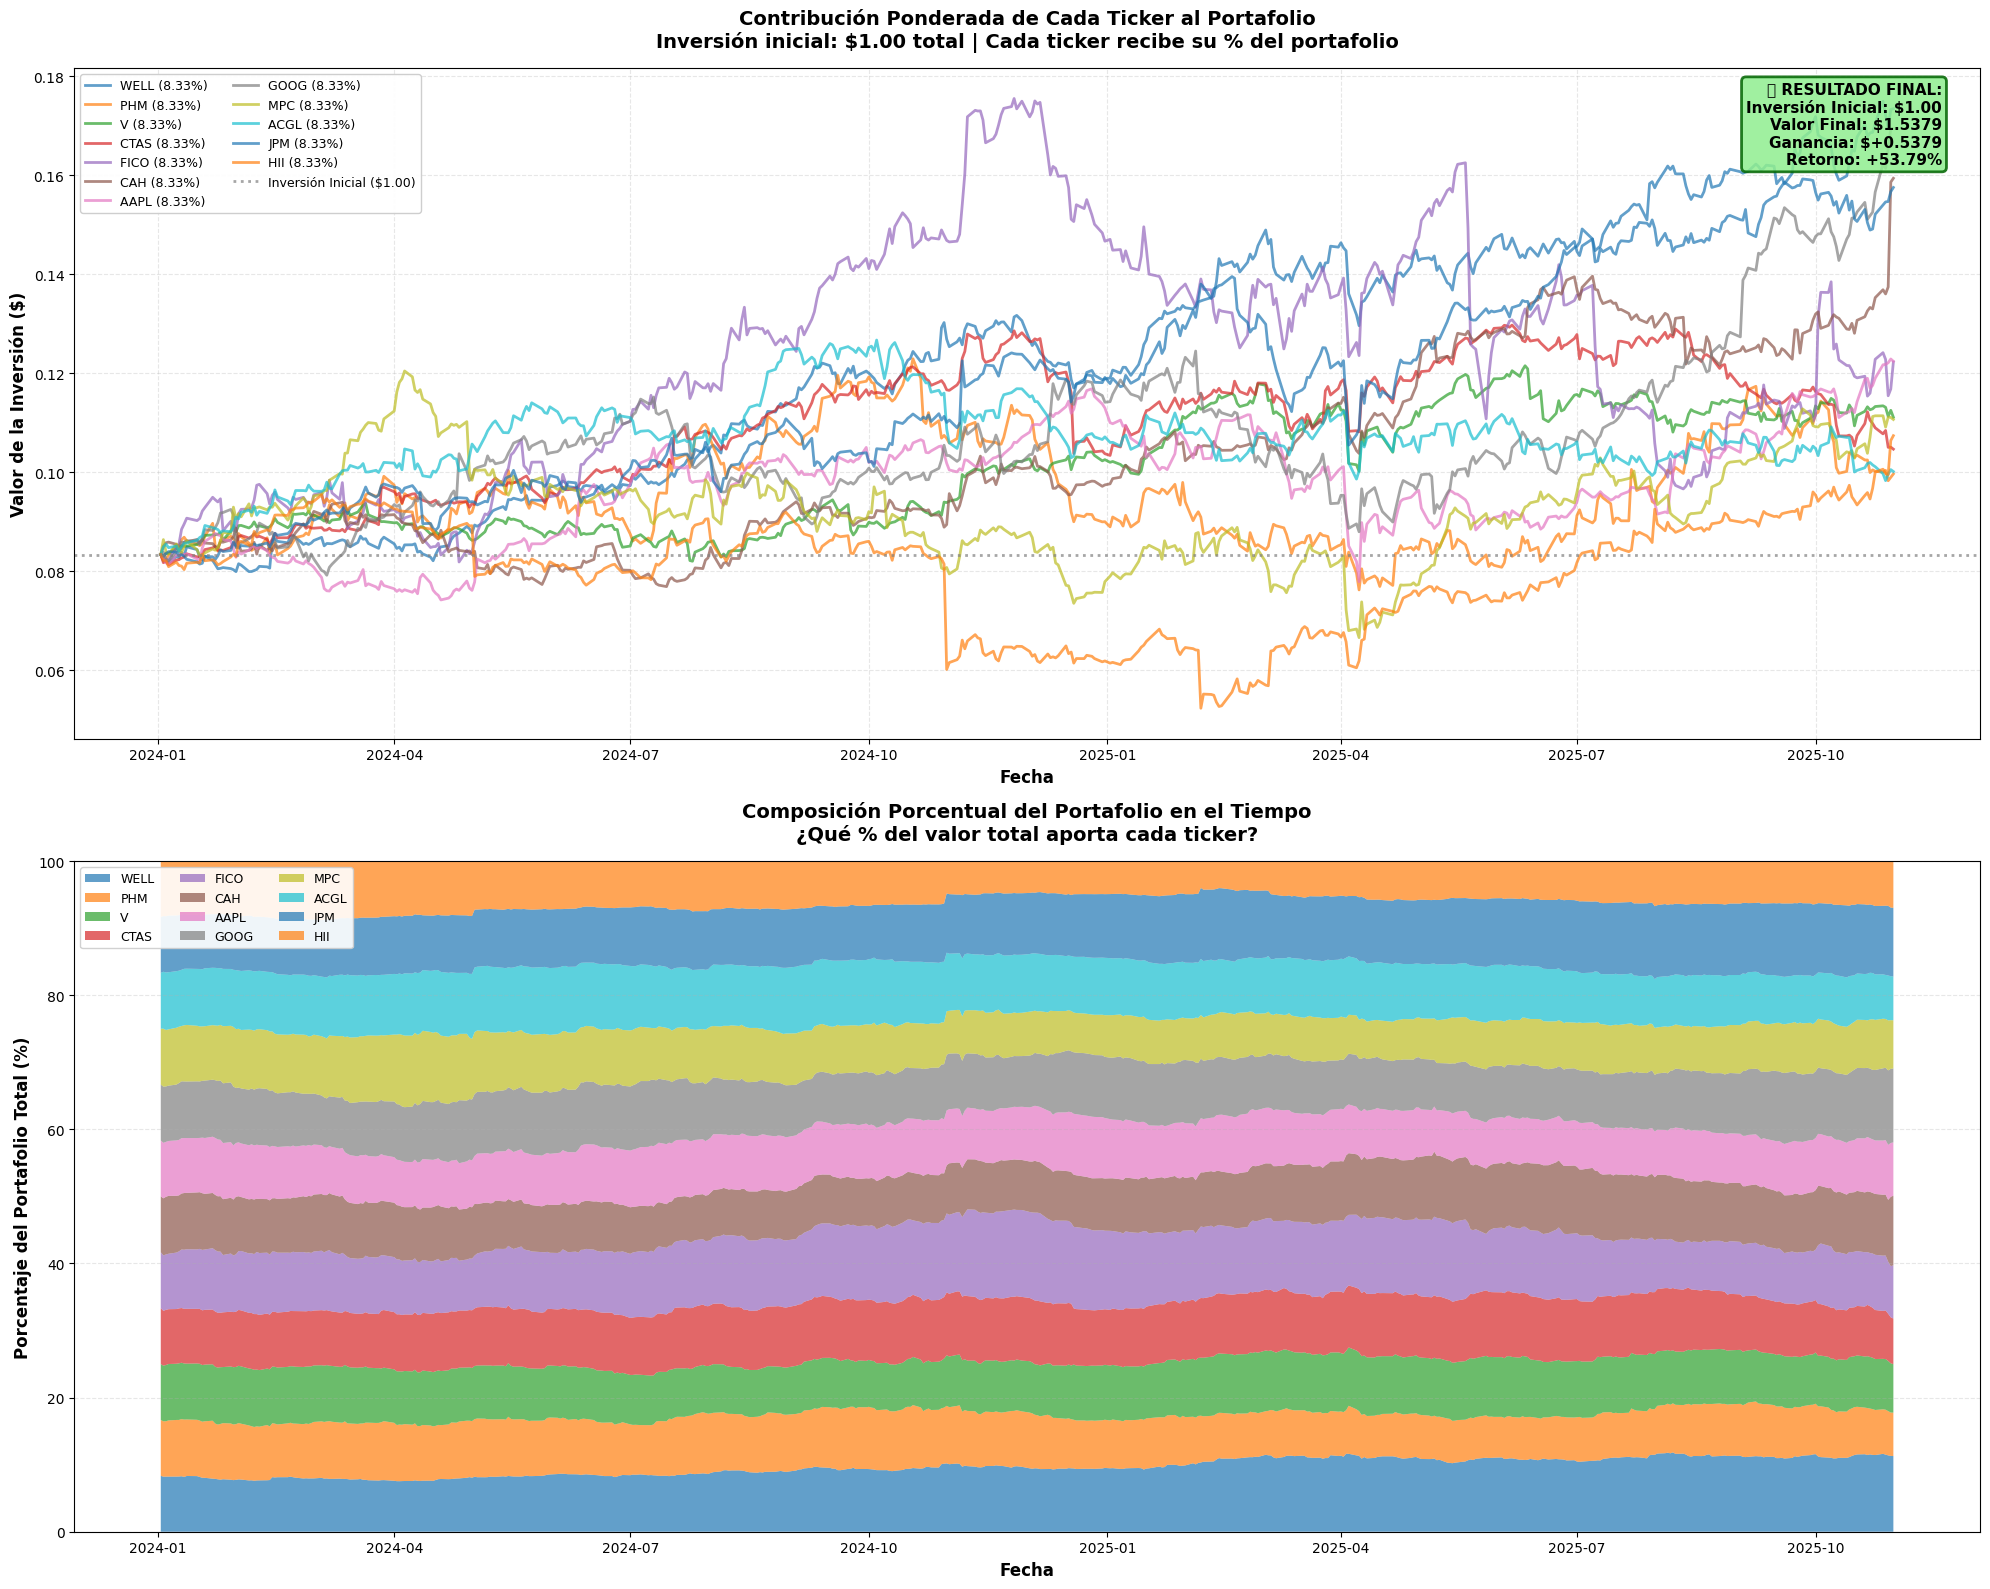


📊 RESUMEN DE VALIDACIÓN:
   Inversión inicial total: $1.00
   Valor final total: $1.5379
   Ganancia total: $+0.5379
   Retorno total: +53.79%
   Días de trading: 461

✅ Gráfica 2 Validación generada


In [70]:
# =======================================================
# 📊 GRÁFICA 2 VALIDACIÓN: TICKERS PONDERADOS - MOVIMIENTO DEL DINERO
# =======================================================

print("\n" + "="*80)
print("📊 GRÁFICA 2 VALIDACIÓN: Contribución Ponderada por Ticker (Valor de Inversión)")
print("="*80)

# Esta gráfica muestra cómo se mueve el dinero invertido en cada ticker
# Si inviertes $1000 en el portafolio total, esta gráfica muestra cuánto vale cada parte

fig, axes = plt.subplots(2, 1, figsize=(20, 16))

# =======================================================================
# PANEL 1: Tickers individuales ponderados (contribución al portafolio)
# =======================================================================
ax1 = axes[0]

print(f"\n💰 Simulación de inversión:")
print(f"   Si inviertes $1.00 total en el portafolio al inicio de validación:")

# Calcular contribución de cada ticker (normalizado × peso)
portfolio_contributions = {}
for ticker in validation_tickers:
    ticker_normalized = validation_prices[ticker] / validation_prices[ticker].iloc[0]
    ticker_weight = portfolio_weights[ticker]
    contribution = ticker_normalized * ticker_weight
    portfolio_contributions[ticker] = contribution
    
    # Graficar
    ax1.plot(validation_prices.index, contribution, 
            alpha=0.7, linewidth=2,
            label=f'{ticker} ({ticker_weight*100:.2f}%)')
    
    # Imprimir resumen
    valor_inicial = ticker_weight
    valor_final = contribution.iloc[-1]
    ganancia = valor_final - valor_inicial
    ret_pct = (valor_final / valor_inicial - 1) * 100
    print(f"   • {ticker:5s}: ${valor_inicial:.4f} → ${valor_final:.4f} ({ret_pct:+.2f}%)")

# Portafolio total (suma de contribuciones)
portfolio_total = sum(portfolio_contributions.values())
#ax1.plot(validation_prices.index, portfolio_total, 
       # linewidth=4.5, color='black', label='💰 PORTAFOLIO TOTAL', 
       # alpha=0.95, zorder=100, linestyle='-')

# Línea de referencia en 1.0 (inversión inicial)
ax1.axhline(y=0.0833, color='gray', linestyle=':', linewidth=2, alpha=0.7, 
           label='Inversión Inicial ($1.00)')

# Configuración
ax1.set_title('Contribución Ponderada de Cada Ticker al Portafolio\n' +
             f'Inversión inicial: $1.00 total | Cada ticker recibe su % del portafolio',
             fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Fecha', fontsize=12, fontweight='bold')
ax1.set_ylabel('Valor de la Inversión ($)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Leyenda
if len(validation_tickers) <= 12:
    ax1.legend(fontsize=9, loc='upper left', ncol=2, framealpha=0.95)
else:
    handles = [
        plt.Line2D([0], [0], color='black', linewidth=4.5, label='💰 PORTAFOLIO TOTAL'),
        plt.Line2D([0], [0], color='gray', linewidth=2, linestyle=':', 
                  label=f'{len(validation_tickers)} Tickers (ponderados)')
    ]
    ax1.legend(handles=handles, fontsize=11, loc='upper left', framealpha=0.95)

# Anotación con valor final
valor_final_total = portfolio_total.iloc[-1]
ganancia_total = valor_final_total - 1.0
ret_total = (valor_final_total - 1.0) * 100

textstr = f'💰 RESULTADO FINAL:\n'
textstr += f'Inversión Inicial: $1.00\n'
textstr += f'Valor Final: ${valor_final_total:.4f}\n'
textstr += f'Ganancia: ${ganancia_total:+.4f}\n'
textstr += f'Retorno: {ret_total:+.2f}%'

ax1.text(0.98, 0.98, textstr, transform=ax1.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.85, 
                 edgecolor='darkgreen', linewidth=2))

# =======================================================================
# PANEL 2: Desglose porcentual (áreas apiladas)
# =======================================================================
ax2 = axes[1]

# Crear matriz para área apilada
contributions_matrix = pd.DataFrame(portfolio_contributions)
contributions_pct = contributions_matrix.div(contributions_matrix.sum(axis=1), axis=0) * 100

# Graficar áreas apiladas
ax2.stackplot(contributions_pct.index, 
             *[contributions_pct[ticker] for ticker in validation_tickers],
             labels=validation_tickers if len(validation_tickers) <= 12 else None,
             alpha=0.7)

# Configuración
ax2.set_title('Composición Porcentual del Portafolio en el Tiempo\n' +
             '¿Qué % del valor total aporta cada ticker?',
             fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Fecha', fontsize=12, fontweight='bold')
ax2.set_ylabel('Porcentaje del Portafolio Total (%)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')

if len(validation_tickers) <= 12:
    ax2.legend(loc='upper left', ncol=3, fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

# Resumen final
print(f"\n📊 RESUMEN DE VALIDACIÓN:")
print(f"   Inversión inicial total: $1.00")
print(f"   Valor final total: ${valor_final_total:.4f}")
print(f"   Ganancia total: ${ganancia_total:+.4f}")
print(f"   Retorno total: {ret_total:+.2f}%")
print(f"   Días de trading: {len(validation_data)}")

print(f"\n✅ Gráfica 2 Validación generada")
print("="*80)
